# Thai Typing Analysis: Descriptive, Euclidean, DTW, and Hierarchical Clustering

This notebook is the main **pre-Matrix-Profile** analysis notebook for the Thai prompt-copying time-series mining project. It assumes the transformation notebook has already exported the event-level, prompt-position, trial-level, participant-level, and QC tables.

## Purpose

This notebook focuses only on four stages:

1. Descriptive and sanity analysis
2. Euclidean baseline analysis
3. DTW analysis
4. Hierarchical clustering

It is organized to answer the course-aligned research questions:

- **RQ1**: Character- and zone-level fluency
- **RQ2**: Linguistic friction versus keyboard-layout friction
- **RQ3**: Shared difficulty regions across users
- **RQ4**: Recovery style as a behavioral signature

## Scope note

This notebook intentionally does **not** implement:

- Matrix Profile
- lower-bound acceleration
- SAX

Those are deferred to a later notebook so that this notebook remains the canonical descriptive and DTW/clustering stage.


## Analysis Roadmap

- Load the transformed outputs and audit the QC filter.
- Fix Thai font rendering for all saved figures.
- Build descriptive views at the prompt, participant, prompt-position, keyboard-demand, and recovery-episode levels.
- Establish Euclidean baselines where lockstep comparison is appropriate.
- Construct DTW-ready sequence objects from the transformed tables.
- Use DTW and hierarchical clustering to study shared prompt difficulty and recovery style.
- Fit a small transparent modeling block for RQ2.
- Save tables, figures, distance matrices, cluster outputs, and a manifest for handoff.


In [1]:
from __future__ import annotations

import json
import math
import os
import shutil
import subprocess
import textwrap
import urllib.request
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib import font_manager as fm
from scipy.cluster.hierarchy import dendrogram, fcluster, leaves_list, linkage
from scipy.spatial.distance import pdist, squareform
import statsmodels.formula.api as smf

np.random.seed(42)
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)
plt.style.use('default')
warnings.filterwarnings('ignore', message='.*tight_layout.*')
warnings.filterwarnings('ignore', message='Glyph .* missing from font.*')


In [2]:
# Editable configuration
NOTEBOOK_ROOT = Path.cwd()
TRANSFORM_OUTPUT_DIR = NOTEBOOK_ROOT / 'outputs' / '01_time_series_transformation_and_pilot_visualization'

TRIAL_QC_PATH = TRANSFORM_OUTPUT_DIR / 'trial_qc.csv'
SESSION_QC_PATH = TRANSFORM_OUTPUT_DIR / 'session_qc.csv'
TRIAL_FEATURES_PATH = TRANSFORM_OUTPUT_DIR / 'trial_features.csv'
PROMPT_POSITION_FEATURES_PATH = TRANSFORM_OUTPUT_DIR / 'prompt_position_features.csv'
PROMPT_POSITION_SEQUENCE_READY_PATH = TRANSFORM_OUTPUT_DIR / 'prompt_position_sequence_ready.csv'
EVENT_SEQUENCE_CORE_PATH = TRANSFORM_OUTPUT_DIR / 'event_sequence_core.csv'
EVENT_SEQUENCE_ENRICHED_PATH = TRANSFORM_OUTPUT_DIR / 'event_sequence_enriched.csv'
ERROR_EPISODE_SUMMARY_PATH = TRANSFORM_OUTPUT_DIR / 'error_episode_summary.csv'
PARTICIPANT_KEYBOARD_PROFILE_PATH = TRANSFORM_OUTPUT_DIR / 'participant_keyboard_profile.csv'
PROJECT_CONTEXT_MD_PATH = NOTEBOOK_ROOT / 'Project_Contexts' / '01_project_context_comprehensive.md'
TRANSFORM_GUIDE_MD_PATH = NOTEBOOK_ROOT / 'Project_Contexts' / '03_transformed_csv_outputs_and_ts_objects_guide.md'
COURSE_CONTEXT_MD_PATH = NOTEBOOK_ROOT / 'Project_Contexts' / '04_analysis_plan_pre_matrix_profile.md'
OUTPUT_DIR = NOTEBOOK_ROOT / 'outputs' / '02_analysis_descriptive_euclidean_dtw_clustering'

TABLE_DIR = OUTPUT_DIR / 'tables'
FIGURE_DIR = OUTPUT_DIR / 'figures'
DISTANCE_DIR = OUTPUT_DIR / 'distance_matrices'
CLUSTER_DIR = OUTPUT_DIR / 'cluster_outputs'
LOG_DIR = OUTPUT_DIR / 'logs'
FONT_DIR = OUTPUT_DIR / 'fonts'
for path in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, DISTANCE_DIR, CLUSTER_DIR, LOG_DIR, FONT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Runtime controls for the heavier analyses
DTW_EVENT_BAND_RATIO = 0.12
DTW_POSITION_BAND_RATIO = 0.08
DTW_EPISODE_BAND_RATIO = 0.15
EPISODE_CONTEXT_BEFORE = 3
EPISODE_CONTEXT_AFTER = 3
MAX_ERROR_EPISODES_FOR_DTW = 120
EUCLIDEAN_FRICTION_RESAMPLE_LEN = 100
PARTICIPANT_CLUSTER_K = 3
TRIAL_CLUSTER_K = 3
EPISODE_CLUSTER_K = 4
SAME_PROMPT_POSITION_CLUSTER_K = 3

analysis_manifest: list[dict] = []


In [3]:
def register_output(path: Path, kind: str, description: str) -> Path:
    path = Path(path)
    analysis_manifest.append({'path': str(path), 'kind': kind, 'description': description})
    return path


def save_dataframe(df: pd.DataFrame, path: Path, description: str, index: bool = True) -> Path:
    path = register_output(path, 'table', description)
    df.to_csv(path, index=index, encoding='utf-8-sig')
    return path


def save_text(text: str, path: Path, description: str) -> Path:
    path = register_output(path, 'text', description)
    path.write_text(text, encoding='utf-8')
    return path


def save_json(payload: dict, path: Path, description: str) -> Path:
    path = register_output(path, 'json', description)
    path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding='utf-8')
    return path


def save_figure(fig: plt.Figure, path: Path, description: str) -> Path:
    path = register_output(path, 'figure', description)
    fig.savefig(path, dpi=180, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    return path


def load_csv_required(path: Path, label: str) -> pd.DataFrame:
    if not Path(path).exists():
        raise FileNotFoundError(f'{label} not found: {path}')
    return pd.read_csv(path)


def load_text_optional(path: Path) -> str:
    if not Path(path).exists():
        return ''
    return Path(path).read_text(encoding='utf-8')


def stringify_profile_value(value) -> str:
    if pd.isna(value):
        return '<missing>'
    if isinstance(value, (bool, np.bool_)):
        return str(int(value))
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    if isinstance(value, float) and value.is_integer():
        return str(int(value))
    return str(value)


def derive_prompt_family(frame: pd.DataFrame) -> pd.Series:
    if 'prompt_family' in frame.columns:
        return frame['prompt_family'].astype(str)
    if 'condition' in frame.columns:
        return frame['condition'].astype(str)
    if 'length_class' in frame.columns:
        return frame['length_class'].astype(str)
    return frame['prompt_id'].astype(str)


def truncate_text(text: str, width: int = 32) -> str:
    text = '' if pd.isna(text) else str(text)
    if len(text) <= width:
        return text
    return text[: max(width - 1, 1)] + '…'


def prompt_display_label(prompt_id: str, prompt_text: str, width: int = 22) -> str:
    return f"{prompt_id} | {truncate_text(prompt_text, width)}"


def top_n_joined(series: pd.Series, n: int = 3) -> str:
    counts = series.dropna().astype(str).value_counts().head(n)
    if counts.empty:
        return ''
    return ', '.join([f'{idx} ({count})' for idx, count in counts.items()])


def normalize_binary_string(value: str) -> str:
    value = stringify_profile_value(value)
    mapping = {'0': 'No', '1': 'Yes', '<missing>': '<missing>'}
    return mapping.get(value, value)


def off_diagonal_values(matrix: np.ndarray) -> np.ndarray:
    if matrix.shape[0] <= 1:
        return np.array([], dtype=float)
    mask = ~np.eye(matrix.shape[0], dtype=bool)
    return matrix[mask]


def plot_bar(df: pd.DataFrame, x_col: str, y_col: str, title: str, ylabel: str, out_path: Path, color: str = '#4472c4') -> None:
    fig, ax = plt.subplots(figsize=(max(10, len(df) * 0.55), 5.5))
    ax.bar(np.arange(len(df)), df[y_col], color=color)
    ax.set_xticks(np.arange(len(df)))
    ax.set_xticklabels(df[x_col], rotation=45, ha='right')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    save_figure(fig, out_path, title)


def plot_heatmap(matrix: np.ndarray, row_labels: list[str], col_labels: list[str], title: str, out_path: Path, cmap: str = 'viridis', colorbar_label: str = '', figsize: tuple[float, float] | None = None) -> None:
    n_rows, n_cols = matrix.shape
    if figsize is None:
        figsize = (max(7, n_cols * 0.35), max(5, n_rows * 0.28))
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(matrix, aspect='auto', cmap=cmap)
    ax.set_title(title)
    ax.set_xticks(np.arange(n_cols))
    ax.set_yticks(np.arange(n_rows))
    ax.set_xticklabels(col_labels, rotation=90)
    ax.set_yticklabels(row_labels)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    cbar = fig.colorbar(im, ax=ax, shrink=0.9)
    if colorbar_label:
        cbar.set_label(colorbar_label)
    fig.tight_layout()
    save_figure(fig, out_path, title)


def plot_distance_heatmap(distance_df: pd.DataFrame, title: str, out_path: Path, cmap: str = 'magma', figsize: tuple[float, float] | None = None) -> None:
    plot_heatmap(distance_df.to_numpy(), distance_df.index.tolist(), distance_df.columns.tolist(), title, out_path, cmap=cmap, colorbar_label='Distance', figsize=figsize)


def build_participant_keyboard_profile_main(event_enriched: pd.DataFrame, prompt_position_features: pd.DataFrame) -> pd.DataFrame:
    event_dimensions = [
        ('expected_layout', 'expected_layout_required'),
        ('expected_shift_required', 'expected_shift_required'),
        ('layout_switch_needed', 'layout_switch_needed'),
        ('target_distance_bin', 'target_distance_bin'),
        ('expected_char_class', 'expected_char_class'),
        ('expected_zone_proxy', 'expected_zone_proxy'),
        ('expected_hand_proxy', 'expected_hand_proxy'),
    ]
    position_dimensions = [
        ('expected_layout', 'layout_required_j'),
        ('expected_shift_required', 'shift_required_j'),
        ('layout_switch_needed', 'layout_switch_into_j'),
        ('target_distance_bin', 'distance_from_prev_bin_j'),
        ('expected_char_class', 'char_class_j'),
        ('expected_zone_proxy', 'zone_proxy_j'),
        ('expected_hand_proxy', 'hand_proxy_j'),
    ]

    profile_frames = []
    event_base = event_enriched.loc[event_enriched['expected_pos'].notna()].copy()
    position_base = prompt_position_features.copy()

    for (dimension_name, event_column), (_, position_column) in zip(event_dimensions, position_dimensions):
        event_part = (
            event_base.groupby(['participant_code', event_column], dropna=False)
            .agg(
                n_events=('event_index', 'size'),
                n_trials_from_events=('trial_uid', 'nunique'),
                mean_log_dt_ms=('log_dt_ms', 'mean'),
                mean_friction=('friction', 'mean'),
                delete_rate=('is_delete', 'mean'),
                near_key_typo_rate=('is_near_key_typo', 'mean'),
                layout_confusion_rate=('is_layout_confusion', 'mean'),
                shift_confusion_rate=('is_shift_confusion', 'mean'),
            )
            .reset_index()
            .rename(columns={event_column: 'profile_value_raw'})
        )

        position_part = (
            position_base.groupby(['participant_code', position_column], dropna=False)
            .agg(
                n_positions=('prompt_position', 'size'),
                n_trials_from_positions=('trial_uid', 'nunique'),
                mean_time_to_first_correct_ms=('time_to_first_correct_ms', 'mean'),
                mean_time_to_stability_ms=('time_to_stability_ms', 'mean'),
                mean_revisions=('revisions', 'mean'),
                wrong_first_rate=('wrong_first', 'mean'),
            )
            .reset_index()
            .rename(columns={position_column: 'profile_value_raw'})
        )

        merged = event_part.merge(position_part, on=['participant_code', 'profile_value_raw'], how='outer')
        merged['profile_dimension'] = dimension_name
        merged['profile_value'] = merged['profile_value_raw'].map(stringify_profile_value)
        profile_frames.append(merged.drop(columns=['profile_value_raw']))

    profile = pd.concat(profile_frames, ignore_index=True, sort=False)
    ordered_columns = [
        'participant_code',
        'profile_dimension',
        'profile_value',
        'n_events',
        'n_positions',
        'n_trials_from_events',
        'n_trials_from_positions',
        'mean_log_dt_ms',
        'mean_friction',
        'delete_rate',
        'near_key_typo_rate',
        'layout_confusion_rate',
        'shift_confusion_rate',
        'mean_time_to_first_correct_ms',
        'mean_time_to_stability_ms',
        'mean_revisions',
        'wrong_first_rate',
    ]
    return profile[ordered_columns].sort_values(['participant_code', 'profile_dimension', 'profile_value']).reset_index(drop=True)


## Thai Font Setup and Verification

The previous notebook produced missing-glyph warnings for Thai labels in Matplotlib. This section detects available Thai-capable fonts, tries to install one locally if needed, rebuilds the font cache when appropriate, configures Matplotlib, and saves a Thai render test figure.


In [4]:
def _font_names_from_fc_list() -> list[str]:
    if shutil.which('fc-list') is None:
        return []
    try:
        result = subprocess.run(['fc-list', ':lang=th', 'family'], capture_output=True, text=True, check=True)
    except Exception:
        return []
    names: list[str] = []
    for line in result.stdout.splitlines():
        for name in line.split(','):
            name = name.strip()
            if name and name not in names:
                names.append(name)
    return names


def rebuild_matplotlib_font_cache() -> list[str]:
    cache_dir = Path(mpl.get_cachedir())
    removed = []
    for cache_file in cache_dir.glob('fontlist-v*.json'):
        try:
            cache_file.unlink()
            removed.append(str(cache_file))
        except OSError:
            pass
    try:
        fm._load_fontmanager(try_read_cache=False)
    except Exception:
        pass
    return removed


def setup_thai_font_for_matplotlib(font_dir: Path = FONT_DIR, test_output_dir: Path = FIGURE_DIR) -> dict:
    preferred_fonts = [
        'Noto Sans Thai',
        'Sarabun',
        'TH Sarabun New',
        'Tahoma',
        'Noto Sans Thai Looped',
        'Kinnari',
        'Garuda',
        'Waree',
        'Loma',
        'Laksaman',
        'Kanit',
    ]
    downloadable_fonts = [
        (
            'Noto Sans Thai',
            'NotoSansThai-Regular.ttf',
            'https://raw.githubusercontent.com/notofonts/noto-fonts/main/hinted/ttf/NotoSansThai/NotoSansThai-Regular.ttf',
        ),
        (
            'Sarabun',
            'Sarabun-Regular.ttf',
            'https://raw.githubusercontent.com/google/fonts/main/ofl/sarabun/Sarabun-Regular.ttf',
        ),
    ]

    font_dir.mkdir(parents=True, exist_ok=True)
    available_before = sorted({font.name for font in fm.fontManager.ttflist})
    fc_candidates = _font_names_from_fc_list()

    def first_available(candidates: list[str]) -> str | None:
        current = {font.name for font in fm.fontManager.ttflist}
        for candidate in candidates:
            if candidate in current:
                return candidate
        return None

    selected_font = first_available(preferred_fonts + fc_candidates)
    downloaded_files = []
    cache_removed = []

    if selected_font is None:
        for font_name, filename, url in downloadable_fonts:
            target_path = font_dir / filename
            if not target_path.exists():
                try:
                    urllib.request.urlretrieve(url, target_path)
                    downloaded_files.append(str(target_path))
                except Exception:
                    continue
            try:
                fm.fontManager.addfont(str(target_path))
            except Exception:
                continue

        if downloaded_files:
            if shutil.which('fc-cache') is not None:
                try:
                    subprocess.run(['fc-cache', '-f', str(font_dir)], check=False, capture_output=True, text=True)
                except Exception:
                    pass
            cache_removed = rebuild_matplotlib_font_cache()
            try:
                fm.fontManager.addfont(str(font_dir / 'NotoSansThai-Regular.ttf'))
            except Exception:
                pass
            try:
                fm.fontManager.addfont(str(font_dir / 'Sarabun-Regular.ttf'))
            except Exception:
                pass
            selected_font = first_available(preferred_fonts + fc_candidates)

    if selected_font is None:
        fallback_candidates = fc_candidates + ['DejaVu Sans']
        selected_font = fallback_candidates[0] if fallback_candidates else 'DejaVu Sans'

    mpl.rcParams['font.family'] = [selected_font, 'DejaVu Sans']
    mpl.rcParams['axes.unicode_minus'] = False
    mpl.rcParams['figure.facecolor'] = 'white'

    test_text = 'ทดสอบการแสดงผลภาษาไทย: สวัสดี วันนี้เราจะวิเคราะห์พฤติกรรมการพิมพ์'
    fig, ax = plt.subplots(figsize=(10, 2.6))
    ax.text(0.02, 0.62, test_text, fontsize=15)
    ax.text(0.02, 0.24, f'Active Matplotlib font: {selected_font}', fontsize=11)
    ax.set_axis_off()
    fig.tight_layout()
    test_path = test_output_dir / 'thai_font_render_test.png'
    save_figure(fig, test_path, 'Thai font render test figure')

    summary = {
        'selected_font': selected_font,
        'available_before_count': len(available_before),
        'fc_list_candidates': fc_candidates,
        'downloaded_files': downloaded_files,
        'cache_files_removed': cache_removed,
        'test_figure_path': str(test_path),
    }
    save_json(summary, LOG_DIR / 'thai_font_setup_summary.json', 'Thai font setup summary')
    return summary


thai_font_info = setup_thai_font_for_matplotlib()
print(json.dumps(thai_font_info, ensure_ascii=False, indent=2))


{
  "selected_font": "TH Sarabun New",
  "available_before_count": 328,
  "fc_list_candidates": [
    "Kanit",
    "Kanit Black",
    "Kanit Medium",
    "Thonburi",
    "TH SarabunPSK",
    "TH Sarabun New",
    "Kanit Thin",
    "Ayuthaya",
    "BoonJot",
    "Bai Jamjuree",
    "Sukhumvit Set",
    ".LastResort",
    "Silom",
    "Microsoft Sans Serif",
    "TH Niramit AS",
    "Bai Jamjuree ExtraLight",
    "Kanit SemiBold",
    ".ThonburiUI",
    "Kanit Light",
    "Krungthep",
    "Arial Unicode MS",
    ".ThonburiUIWatch",
    "Bai Jamjuree SemiBold",
    "Kanit ExtraBold",
    "Sriracha",
    "Bai Jamjuree Light",
    "Sathu",
    "Bai Jamjuree Medium",
    "Tahoma",
    "Itim",
    "Kanit ExtraLight"
  ],
  "downloaded_files": [],
  "cache_files_removed": [],
  "test_figure_path": "/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/02_analysis_descriptive_euclidean_dtw_clustering/figures/thai_font_render_test.png"
}


## Load Transformed Inputs

The notebook loads the transformed tables, records basic provenance, and then reconstructs a **main-only** participant profile inside the notebook so that practice-trial aggregation does not affect the main analyses.


In [5]:
trial_qc = load_csv_required(TRIAL_QC_PATH, 'Trial QC')
session_qc = load_csv_required(SESSION_QC_PATH, 'Session QC')
trial_features = load_csv_required(TRIAL_FEATURES_PATH, 'Trial features')
prompt_position_features = load_csv_required(PROMPT_POSITION_FEATURES_PATH, 'Prompt-position features')
prompt_position_sequence_ready = load_csv_required(PROMPT_POSITION_SEQUENCE_READY_PATH, 'Prompt-position sequence-ready table')
event_sequence_core = load_csv_required(EVENT_SEQUENCE_CORE_PATH, 'Event sequence core table')
event_sequence_enriched = load_csv_required(EVENT_SEQUENCE_ENRICHED_PATH, 'Event sequence enriched table')
error_episode_summary = load_csv_required(ERROR_EPISODE_SUMMARY_PATH, 'Error episode summary')
participant_keyboard_profile_exported = load_csv_required(PARTICIPANT_KEYBOARD_PROFILE_PATH, 'Participant keyboard profile export')

project_context_text = load_text_optional(PROJECT_CONTEXT_MD_PATH)
transform_guide_text = load_text_optional(TRANSFORM_GUIDE_MD_PATH)
course_context_text = load_text_optional(COURSE_CONTEXT_MD_PATH)

context_inventory = pd.DataFrame(
    [
        {'context_file': 'project_context', 'path': str(PROJECT_CONTEXT_MD_PATH), 'exists': PROJECT_CONTEXT_MD_PATH.exists(), 'characters': len(project_context_text)},
        {'context_file': 'transform_guide', 'path': str(TRANSFORM_GUIDE_MD_PATH), 'exists': TRANSFORM_GUIDE_MD_PATH.exists(), 'characters': len(transform_guide_text)},
        {'context_file': 'course_context', 'path': str(COURSE_CONTEXT_MD_PATH), 'exists': COURSE_CONTEXT_MD_PATH.exists(), 'characters': len(course_context_text)},
    ]
)
loaded_table_inventory = pd.DataFrame(
    [
        {'table': 'trial_qc', 'rows': len(trial_qc), 'columns': trial_qc.shape[1]},
        {'table': 'session_qc', 'rows': len(session_qc), 'columns': session_qc.shape[1]},
        {'table': 'trial_features', 'rows': len(trial_features), 'columns': trial_features.shape[1]},
        {'table': 'prompt_position_features', 'rows': len(prompt_position_features), 'columns': prompt_position_features.shape[1]},
        {'table': 'prompt_position_sequence_ready', 'rows': len(prompt_position_sequence_ready), 'columns': prompt_position_sequence_ready.shape[1]},
        {'table': 'event_sequence_core', 'rows': len(event_sequence_core), 'columns': event_sequence_core.shape[1]},
        {'table': 'event_sequence_enriched', 'rows': len(event_sequence_enriched), 'columns': event_sequence_enriched.shape[1]},
        {'table': 'error_episode_summary', 'rows': len(error_episode_summary), 'columns': error_episode_summary.shape[1]},
        {'table': 'participant_keyboard_profile_exported', 'rows': len(participant_keyboard_profile_exported), 'columns': participant_keyboard_profile_exported.shape[1]},
    ]
)
display(context_inventory)
display(loaded_table_inventory)

trial_features['duration_per_character'] = trial_features['duration_ms'] / trial_features['prompt_length'].replace(0, np.nan)
save_dataframe(loaded_table_inventory, TABLE_DIR / 'loaded_table_inventory.csv', 'Loaded input table inventory', index=False)
save_dataframe(context_inventory, TABLE_DIR / 'context_inventory.csv', 'Loaded context file inventory', index=False)


,context_file,path,exists,characters
0,project_context,/Users/kongfha/Desktop/Time_Series_Mining/Fina...,True,20059
1,transform_guide,/Users/kongfha/Desktop/Time_Series_Mining/Fina...,True,20904
2,course_context,/Users/kongfha/Desktop/Time_Series_Mining/Fina...,True,23517


,table,rows,columns
0,trial_qc,390,23
1,session_qc,26,9
2,trial_features,390,40
3,prompt_position_features,23374,76
4,prompt_position_sequence_ready,23374,12
5,event_sequence_core,30930,16
6,event_sequence_enriched,30930,189
7,error_episode_summary,1889,18
8,participant_keyboard_profile_exported,832,17


PosixPath('/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/02_analysis_descriptive_euclidean_dtw_clustering/tables/context_inventory.csv')

## QC-Based Filtering

The main analysis keeps only trials that satisfy all of the following:

- `trial_type == "main"`
- `all_core_qc_ok == 1`
- `qc_exact_match_ok == 1`

Practice trials are retained only as optional context but are excluded from all main descriptive, Euclidean, DTW, clustering, and modeling analyses.


In [6]:
trial_qc = trial_qc.copy()
trial_qc['qc_reason'] = np.select(
    [
        trial_qc['trial_type'].ne('main'),
        trial_qc['all_core_qc_ok'].ne(1),
        trial_qc['qc_exact_match_ok'].ne(1),
    ],
    [
        'excluded_non_main_trial',
        'excluded_core_qc_failure',
        'excluded_exact_match_failure',
    ],
    default='kept_main_trial',
)

kept_trial_uids = set(
    trial_qc.loc[
        trial_qc['trial_type'].eq('main')
        & trial_qc['all_core_qc_ok'].eq(1)
        & trial_qc['qc_exact_match_ok'].eq(1),
        'trial_uid',
    ]
)

main_trial_features = trial_features.loc[trial_features['trial_uid'].isin(kept_trial_uids)].copy()
main_prompt_position = prompt_position_features.loc[prompt_position_features['trial_uid'].isin(kept_trial_uids)].copy()
main_prompt_position_sequence = prompt_position_sequence_ready.loc[prompt_position_sequence_ready['trial_uid'].isin(kept_trial_uids)].copy()
main_event_core = event_sequence_core.loc[event_sequence_core['trial_uid'].isin(kept_trial_uids)].copy()
main_event_enriched = event_sequence_enriched.loc[event_sequence_enriched['trial_uid'].isin(kept_trial_uids)].copy()
main_error_episodes = error_episode_summary.loc[error_episode_summary['trial_uid'].isin(kept_trial_uids)].copy()
main_trial_qc = trial_qc.loc[trial_qc['trial_uid'].isin(kept_trial_uids)].copy()

main_trial_features['prompt_family'] = derive_prompt_family(main_trial_features)
main_prompt_position['prompt_family'] = derive_prompt_family(main_prompt_position)
main_error_episodes = main_error_episodes.merge(
    main_trial_features[['trial_uid', 'condition', 'length_class', 'prompt_text', 'prompt_family']],
    on='trial_uid',
    how='left',
)

qc_summary = pd.DataFrame(
    [
        {'metric': 'total_trials', 'value': len(trial_qc)},
        {'metric': 'kept_main_trials', 'value': len(main_trial_qc)},
        {'metric': 'excluded_trials', 'value': len(trial_qc) - len(main_trial_qc)},
        {'metric': 'kept_participants', 'value': main_trial_qc['participant_code'].nunique()},
        {'metric': 'kept_prompts', 'value': main_trial_qc['prompt_id'].nunique()},
    ]
)
qc_reason_counts = trial_qc['qc_reason'].value_counts(dropna=False).rename_axis('qc_reason').reset_index(name='trial_count')

print(f"Total trials: {len(trial_qc):,}")
print(f"Kept main trials: {len(main_trial_qc):,}")
print(f"Excluded trials: {len(trial_qc) - len(main_trial_qc):,}")
display(qc_summary)
display(qc_reason_counts)

save_dataframe(qc_summary, TABLE_DIR / 'qc_summary.csv', 'QC filtering summary', index=False)
save_dataframe(qc_reason_counts, TABLE_DIR / 'qc_reason_counts.csv', 'QC exclusion reasons', index=False)


Total trials: 390
Kept main trials: 364
Excluded trials: 26


,metric,value
0,total_trials,390
1,kept_main_trials,364
2,excluded_trials,26
3,kept_participants,26
4,kept_prompts,14


,qc_reason,trial_count
0,kept_main_trial,364
1,excluded_non_main_trial,26


PosixPath('/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/02_analysis_descriptive_euclidean_dtw_clustering/tables/qc_reason_counts.csv')

## Descriptive Prompt-Level Analysis

This section summarizes each prompt under the main-trial QC filter. It focuses on timing, edits, recovery burden, and typing-friction indicators that can later guide DTW and clustering selections.


In [7]:
prompt_summary = (
    main_trial_features.groupby(['prompt_id', 'prompt_typing_order', 'length_class', 'condition', 'prompt_text', 'prompt_length'], as_index=False)
    .agg(
        n_trials=('trial_uid', 'nunique'),
        mean_duration_ms=('duration_ms', 'mean'),
        mean_duration_per_character=('duration_per_character', 'mean'),
        mean_event_count=('event_count', 'mean'),
        mean_delete_count=('delete_count', 'mean'),
        mean_number_of_error_episodes=('number_of_error_episodes', 'mean'),
        mean_maximum_wrong_suffix_depth=('maximum_wrong_suffix_depth', 'mean'),
        mean_friction=('mean_friction', 'mean'),
        mean_layout_switch_count=('layout_switch_count', 'mean'),
        mean_near_key_typo_count=('near_key_typo_count', 'mean'),
        mean_layout_confusion_count=('layout_confusion_count', 'mean'),
        mean_shift_confusion_count=('shift_confusion_count', 'mean'),
    )
    .sort_values('prompt_typing_order')
    .reset_index(drop=True)
)
prompt_summary['prompt_label'] = [prompt_display_label(pid, text) for pid, text in zip(prompt_summary['prompt_id'], prompt_summary['prompt_text'])]

display(prompt_summary)
save_dataframe(prompt_summary, TABLE_DIR / 'prompt_summary.csv', 'Prompt-level summary table', index=False)

plot_specs = [
    ('mean_duration_ms', 'Mean Duration by Prompt', 'Mean duration (ms)', 'prompt_mean_duration_ms.png', '#35608a'),
    ('mean_duration_per_character', 'Mean Duration per Character by Prompt', 'Mean duration per character (ms)', 'prompt_mean_duration_per_character.png', '#5b8f29'),
    ('mean_delete_count', 'Mean Delete Count by Prompt', 'Mean delete count', 'prompt_mean_delete_count.png', '#b25d2f'),
    ('mean_number_of_error_episodes', 'Mean Number of Error Episodes by Prompt', 'Mean error episodes', 'prompt_mean_error_episodes.png', '#7a3e9d'),
    ('mean_friction', 'Mean Friction by Prompt', 'Mean friction', 'prompt_mean_friction.png', '#a23b72'),
]
for metric, title, ylabel, filename, color in plot_specs:
    plot_bar(prompt_summary, 'prompt_label', metric, title, ylabel, FIGURE_DIR / filename, color=color)

focus_prompts = prompt_summary.sort_values(
    ['mean_number_of_error_episodes', 'mean_friction', 'mean_duration_per_character'],
    ascending=[False, False, False],
)['prompt_id'].tolist()
print('Prompts ranked for downstream DTW/clustering focus:')
print(focus_prompts)


,prompt_id,prompt_typing_order,length_class,condition,prompt_text,prompt_length,n_trials,mean_duration_ms,mean_duration_per_character,mean_event_count,mean_delete_count,mean_number_of_error_episodes,mean_maximum_wrong_suffix_depth,mean_friction,mean_layout_switch_count,mean_near_key_typo_count,mean_layout_confusion_count,mean_shift_confusion_count,prompt_label
0,P01,1,short,familiar_baseline,วันนี้เราจะทำการบ้านให้เสร็จ,28,26,16386.769231,585.241758,37.307692,4.653846,2.846154,1.269231,-0.084074,0.000000,1.538462,0.000000,0.115385,P01 | วันนี้เราจะทำการบ้านใ…
1,P02,2,short,familiar_polite,กรุณาตอบกลับภายในวันนี้,23,26,18638.961538,810.389632,28.076923,2.538462,1.653846,1.192308,-0.023320,0.000000,1.192308,0.038462,0.115385,P02 | กรุณาตอบกลับภายในวันน…
2,P04,3,short,orthographic_named_entity,นิสิตจากจุฬาลงกรณ์มหาวิทยาลัย,29,26,15101.807692,520.751989,36.230769,3.615385,2.346154,1.384615,0.023694,0.000000,1.153846,0.000000,0.115385,P04 | นิสิตจากจุฬาลงกรณ์มหา…
3,P03,4,short,formal_register,ขอความกรุณาจัดทำเอกสารดังกล่าว,30,26,14863.000000,495.433333,42.384615,6.192308,3.115385,2.576923,0.006376,0.000000,2.576923,0.000000,0.076923,P03 | ขอความกรุณาจัดทำเอกสา…
4,P05,5,short,twisted_proverb,เข้าเมืองตาหลิ่ว ต้องหลิ่วมาตาม,31,26,17880.423077,576.787841,48.846154,8.923077,4.000000,3.384615,0.051285,0.000000,2.192308,0.000000,0.000000,P05 | เข้าเมืองตาหลิ่ว ต้อง…
5,P09,6,medium,arabic_numerals,ชั้นมัธยมศึกษาปีที่ 6 จะส่งรายงานจำนวน 10 หน้า,46,26,35302.000000,767.434783,66.461538,10.230769,3.730769,3.884615,0.037695,0.000000,2.807692,0.153846,0.307692,P09 | ชั้นมัธยมศึกษาปีที่ 6…
6,P11,7,medium,rhythmic_repetition,วันนี้ผมทักผมรักผมรอ วันไหนผมท้อผมพอผมลา,40,26,20588.769231,514.719231,50.307692,5.153846,2.346154,2.769231,-0.002675,0.000000,1.307692,0.038462,0.000000,P11 | วันนี้ผมทักผมรักผมรอ …
7,P10,8,medium,thai_numerals,ชั้นมัธยมศึกษาปีที่ ๖ จะส่งรายงานจำนวน ๑๐ หน้า,46,26,48241.346154,1048.724916,65.384615,9.692308,6.076923,2.115385,0.076956,0.000000,1.692308,0.730769,0.500000,P10 | ชั้นมัธยมศึกษาปีที่ ๖…
8,P06,9,medium,mixed_symbols_identification,นักเรียน ม.5/6 ช่วยตรวจสอบ ชื่อ-สกุล ของตัวเอง...,52,26,25566.346154,491.660503,67.692308,7.846154,4.192308,2.538462,0.030030,6.038462,1.961538,1.153846,0.000000,P06 | นักเรียน ม.5/6 ช่วยตร…
9,P08,10,medium,formal_lexical_difficulty,ขอความร่วมมือจัดเตรียมเอกสารเพื่อเป็นวิทยาทานแ...,56,26,21912.692308,391.298077,68.230769,6.115385,2.961538,2.576923,-0.068339,0.000000,2.115385,0.000000,0.000000,P08 | ขอความร่วมมือจัดเตรีย…


Prompts ranked for downstream DTW/clustering focus:
['P13', 'P14', 'P12', 'P07', 'P10', 'P06', 'P05', 'P09', 'P03', 'P08', 'P01', 'P04', 'P11', 'P02']


## Descriptive Participant-Level Analysis

This section describes participant-level trial burden and mean typo-pattern rates under the same main-trial QC filter.


In [8]:
participant_summary = (
    main_trial_features.groupby('participant_code')
    .apply(
        lambda g: pd.Series(
            {
                'n_main_trials': g['trial_uid'].nunique(),
                'mean_trial_duration_ms': g['duration_ms'].mean(),
                'mean_duration_per_character': g['duration_per_character'].mean(),
                'mean_delete_count': g['delete_count'].mean(),
                'mean_friction': g['mean_friction'].mean(),
                'mean_number_of_error_episodes': g['number_of_error_episodes'].mean(),
                'mean_maximum_wrong_suffix_depth': g['maximum_wrong_suffix_depth'].mean(),
                'near_key_typo_rate': g['near_key_typo_count'].sum() / g['event_count'].sum(),
                'layout_confusion_rate': g['layout_confusion_count'].sum() / g['event_count'].sum(),
                'shift_confusion_rate': g['shift_confusion_count'].sum() / g['event_count'].sum(),
            }
        )
    )
    .reset_index()
    .sort_values(['mean_friction', 'mean_trial_duration_ms'], ascending=False)
    .reset_index(drop=True)
)

display(participant_summary)
save_dataframe(participant_summary, TABLE_DIR / 'participant_summary.csv', 'Participant-level summary table', index=False)

participant_order = participant_summary['participant_code'].tolist()
prompt_order = prompt_summary['prompt_id'].tolist()
prompt_label_map = prompt_summary.set_index('prompt_id')['prompt_label'].to_dict()

participant_prompt_duration = (
    main_trial_features.pivot(index='participant_code', columns='prompt_id', values='duration_ms')
    .reindex(index=participant_order, columns=prompt_order)
)
participant_prompt_friction = (
    main_trial_features.pivot(index='participant_code', columns='prompt_id', values='mean_friction')
    .reindex(index=participant_order, columns=prompt_order)
)

save_dataframe(participant_prompt_duration.reset_index(), TABLE_DIR / 'participant_by_prompt_duration_matrix.csv', 'Participant-by-prompt duration matrix', index=False)
save_dataframe(participant_prompt_friction.reset_index(), TABLE_DIR / 'participant_by_prompt_friction_matrix.csv', 'Participant-by-prompt friction matrix', index=False)

plot_heatmap(
    participant_prompt_duration.to_numpy(),
    participant_prompt_duration.index.tolist(),
    [prompt_label_map[p] for p in participant_prompt_duration.columns],
    'Participant × Prompt Heatmap: Duration',
    FIGURE_DIR / 'participant_prompt_duration_heatmap.png',
    cmap='YlOrRd',
    colorbar_label='Duration (ms)',
    figsize=(12, max(6, len(participant_order) * 0.35)),
)
plot_heatmap(
    participant_prompt_friction.to_numpy(),
    participant_prompt_friction.index.tolist(),
    [prompt_label_map[p] for p in participant_prompt_friction.columns],
    'Participant × Prompt Heatmap: Mean Friction',
    FIGURE_DIR / 'participant_prompt_friction_heatmap.png',
    cmap='magma',
    colorbar_label='Mean friction',
    figsize=(12, max(6, len(participant_order) * 0.35)),
)


/var/folders/2m/my6rfccj2lqgy6_6y84lqwsw0000gn/T/ipykernel_47710/435530954.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,participant_code,n_main_trials,mean_trial_duration_ms,mean_duration_per_character,mean_delete_count,mean_friction,mean_number_of_error_episodes,mean_maximum_wrong_suffix_depth,near_key_typo_rate,layout_confusion_rate,shift_confusion_rate
0,DDDD,14.0,63404.500000,1422.819532,13.785714,0.231358,12.000000,1.428571,0.082532,0.000801,0.000000
1,Offroad,14.0,41732.857143,692.600116,1.642857,0.172313,1.500000,0.785714,0.012115,0.000000,0.000000
2,JJ,14.0,52690.428571,879.440420,5.500000,0.170849,3.642857,2.142857,0.010827,0.004921,0.006890
3,Ja,14.0,42170.571429,713.554386,2.428571,0.147182,1.857143,1.000000,0.012903,0.004301,0.001075
4,superidol,14.0,39358.285714,653.151632,8.500000,0.130139,4.071429,3.071429,0.043636,0.001818,0.000000
5,Shimmy,14.0,112402.642857,2276.619758,32.285714,0.097843,14.857143,5.000000,0.065685,0.004530,0.003964
6,sine,14.0,33461.857143,563.600921,7.071429,0.079736,2.857143,3.714286,0.024528,0.002830,0.001887
7,Plub,14.0,32583.428571,559.582289,12.714286,0.074267,3.571429,5.714286,0.046798,0.000821,0.002463
8,Tw,14.0,30408.000000,502.873059,2.357143,0.051648,1.357143,1.500000,0.015086,0.000000,0.000000
9,Mick,14.0,29498.642857,530.226523,6.428571,0.040691,1.357143,5.071429,0.018234,0.000000,0.000960


## Prompt-Position Heatmaps and Regional Curves

These visualizations are central for **RQ3**. For each prompt, the notebook saves a participant-by-position heatmap and an aggregated curve summary showing shared regions of high stabilization cost, high revision count, high wrong-first rate, and high local friction.


In [9]:
prompt_curve_summaries = []

for prompt_id in prompt_order:
    prompt_meta = prompt_summary.loc[prompt_summary['prompt_id'].eq(prompt_id)].iloc[0]
    prompt_text = prompt_meta['prompt_text']
    prompt_subset = main_prompt_position.loc[main_prompt_position['prompt_id'].eq(prompt_id)].copy()
    duration_order = (
        main_trial_features.loc[main_trial_features['prompt_id'].eq(prompt_id), ['participant_code', 'duration_ms']]
        .sort_values('duration_ms', ascending=False)['participant_code']
        .tolist()
    )

    metrics = [
        ('time_to_stability_ms', 'Time to stability (ms)', 'YlOrRd'),
        ('revisions', 'Revisions', 'Blues'),
        ('wrong_first', 'Wrong-first rate / indicator', 'Purples'),
        ('local_mean_friction', 'Local mean friction', 'magma'),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, max(8, len(duration_order) * 0.25 + 3)), constrained_layout=True)
    for ax, (metric, label, cmap) in zip(axes.flat, metrics):
        matrix = (
            prompt_subset.pivot(index='participant_code', columns='prompt_position_1based', values=metric)
            .reindex(index=duration_order)
        )
        im = ax.imshow(matrix.to_numpy(), aspect='auto', cmap=cmap)
        ax.set_title(label)
        ax.set_xticks(np.arange(matrix.shape[1]))
        ax.set_xticklabels(matrix.columns.tolist(), rotation=90)
        ax.set_yticks(np.arange(matrix.shape[0]))
        ax.set_yticklabels(matrix.index.tolist())
        ax.set_xlabel('Prompt position (1-based)')
        ax.set_ylabel('Participant')
        fig.colorbar(im, ax=ax, shrink=0.8)
    fig.suptitle(f'{prompt_id}: participant × position heatmaps | {truncate_text(prompt_text, 55)}', fontsize=14)
    save_figure(fig, FIGURE_DIR / f'prompt_position_heatmaps_{prompt_id}.png', f'Prompt-position heatmaps for {prompt_id}')

    curve_summary = (
        prompt_subset.groupby(['prompt_id', 'prompt_position', 'prompt_position_1based', 'char_j'], as_index=False)
        .agg(
            median_time_to_first_correct_ms=('time_to_first_correct_ms', 'median'),
            median_time_to_stability_ms=('time_to_stability_ms', 'median'),
            median_revisions=('revisions', 'median'),
            mean_wrong_first=('wrong_first', 'mean'),
            mean_local_friction=('local_mean_friction', 'mean'),
        )
        .sort_values('prompt_position_1based')
    )
    curve_summary['prompt_text'] = prompt_text
    curve_summary['prompt_family'] = prompt_meta['condition']
    prompt_curve_summaries.append(curve_summary)
    save_dataframe(curve_summary, TABLE_DIR / f'prompt_position_curve_summary_{prompt_id}.csv', f'Prompt-position curve summary for {prompt_id}', index=False)

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, constrained_layout=True)
    axes[0].plot(curve_summary['prompt_position_1based'], curve_summary['median_time_to_first_correct_ms'], marker='o', label='Median time to first correct')
    axes[0].plot(curve_summary['prompt_position_1based'], curve_summary['median_time_to_stability_ms'], marker='o', label='Median time to stability')
    axes[0].set_ylabel('Milliseconds')
    axes[0].set_title(f'{prompt_id}: aggregated regional timing curves')
    axes[0].grid(alpha=0.25)
    axes[0].legend(loc='upper right')

    axes[1].plot(curve_summary['prompt_position_1based'], curve_summary['median_revisions'], marker='o', color='#35608a', label='Median revisions')
    axes[1].plot(curve_summary['prompt_position_1based'], curve_summary['mean_wrong_first'], marker='o', color='#a23b72', label='Mean wrong-first')
    axes[1].set_ylabel('Revisions / rate')
    axes[1].grid(alpha=0.25)
    axes[1].legend(loc='upper right')

    axes[2].plot(curve_summary['prompt_position_1based'], curve_summary['mean_local_friction'], marker='o', color='#b25d2f')
    axes[2].set_xlabel('Prompt position (1-based)')
    axes[2].set_ylabel('Mean local friction')
    axes[2].grid(alpha=0.25)
    char_labels = [truncate_text(ch, 2) for ch in curve_summary['char_j']]
    axes[2].set_xticks(curve_summary['prompt_position_1based'])
    axes[2].set_xticklabels([f'{pos}:{ch}' for pos, ch in zip(curve_summary['prompt_position_1based'], char_labels)], rotation=0)

    save_figure(fig, FIGURE_DIR / f'prompt_position_curves_{prompt_id}.png', f'Prompt-position aggregated curves for {prompt_id}')

all_prompt_curve_summary = pd.concat(prompt_curve_summaries, ignore_index=True)
save_dataframe(all_prompt_curve_summary, TABLE_DIR / 'all_prompt_position_curve_summaries.csv', 'All prompt-position curve summaries', index=False)
display(all_prompt_curve_summary.head())


,prompt_id,prompt_position,prompt_position_1based,char_j,median_time_to_first_correct_ms,median_time_to_stability_ms,median_revisions,mean_wrong_first,mean_local_friction,prompt_text,prompt_family
0,P01,0,1,ว,1624.5,1624.5,0.0,0.076923,0.589242,วันนี้เราจะทำการบ้านให้เสร็จ,familiar_baseline
1,P01,1,2,ั,1834.5,1834.5,0.0,0.000000,-0.194419,วันนี้เราจะทำการบ้านให้เสร็จ,familiar_baseline
2,P01,2,3,น,2045.5,2045.5,0.0,0.000000,-0.265339,วันนี้เราจะทำการบ้านให้เสร็จ,familiar_baseline
3,P01,3,4,น,2419.5,2419.5,0.0,0.038462,-0.351769,วันนี้เราจะทำการบ้านให้เสร็จ,familiar_baseline
4,P01,4,5,ี,2886.5,2886.5,0.0,0.115385,-0.223726,วันนี้เราจะทำการบ้านให้เสร็จ,familiar_baseline


## Keyboard-Demand Summaries

This section addresses **RQ1** and supports **RQ2** by comparing fluency across keyboard-demand categories such as layout, shift requirement, layout switches, character class, zone, hand, and distance bins.

Because the exported `participant_keyboard_profile.csv` is pre-aggregated and does not expose `trial_type`, the notebook reconstructs a **main-only** version from the filtered event and prompt-position tables. The exported file is still loaded for provenance.


In [10]:
participant_profile_main = build_participant_keyboard_profile_main(main_event_enriched, main_prompt_position)
save_dataframe(participant_profile_main, TABLE_DIR / 'participant_keyboard_profile_main_only.csv', 'Main-only participant keyboard profile', index=False)

profile_summary_by_dimension = (
    participant_profile_main.groupby(['profile_dimension', 'profile_value'], as_index=False)
    .agg(
        n_participants=('participant_code', 'nunique'),
        mean_time_to_stability_ms=('mean_time_to_stability_ms', 'mean'),
        mean_time_to_first_correct_ms=('mean_time_to_first_correct_ms', 'mean'),
        mean_revisions=('mean_revisions', 'mean'),
        wrong_first_rate=('wrong_first_rate', 'mean'),
        mean_friction=('mean_friction', 'mean'),
        delete_rate=('delete_rate', 'mean'),
        near_key_typo_rate=('near_key_typo_rate', 'mean'),
        layout_confusion_rate=('layout_confusion_rate', 'mean'),
        shift_confusion_rate=('shift_confusion_rate', 'mean'),
    )
    .sort_values(['profile_dimension', 'profile_value'])
    .reset_index(drop=True)
)
save_dataframe(profile_summary_by_dimension, TABLE_DIR / 'keyboard_demand_profile_summary.csv', 'Keyboard-demand summary aggregated across participants', index=False)

demand_position_summary = []
demand_columns = [
    ('layout_required_j', 'expected_layout'),
    ('shift_required_j', 'expected_shift_required'),
    ('layout_switch_into_j', 'layout_switch_needed'),
    ('char_class_j', 'expected_char_class'),
    ('zone_proxy_j', 'expected_zone_proxy'),
    ('hand_proxy_j', 'expected_hand_proxy'),
    ('distance_from_prev_bin_j', 'target_distance_bin'),
]
for position_col, profile_dimension in demand_columns:
    summary = (
        main_prompt_position.groupby(position_col, dropna=False, as_index=False)
        .agg(
            n_positions=('prompt_position', 'size'),
            mean_time_to_stability_ms=('time_to_stability_ms', 'mean'),
            mean_time_to_first_correct_ms=('time_to_first_correct_ms', 'mean'),
            mean_revisions=('revisions', 'mean'),
            wrong_first_rate=('wrong_first', 'mean'),
            mean_friction=('local_mean_friction', 'mean'),
        )
        .rename(columns={position_col: 'profile_value'})
    )
    summary['profile_dimension'] = profile_dimension
    summary['profile_value'] = summary['profile_value'].map(stringify_profile_value)
    demand_position_summary.append(summary)

demand_position_summary = pd.concat(demand_position_summary, ignore_index=True)
save_dataframe(demand_position_summary, TABLE_DIR / 'keyboard_demand_position_summary.csv', 'Keyboard-demand prompt-position summary', index=False)

display(profile_summary_by_dimension.head(12))

class_level = profile_summary_by_dimension.loc[profile_summary_by_dimension['profile_dimension'].eq('expected_char_class')].copy()
class_level = class_level.loc[class_level['profile_value'].ne('<missing>')].sort_values('mean_time_to_stability_ms', ascending=False)
plot_bar(class_level, 'profile_value', 'mean_time_to_stability_ms', 'Character Class: Mean Time to Stability', 'Mean time to stability (ms)', FIGURE_DIR / 'keyboard_demand_char_class_time_to_stability.png', color='#35608a')

shift_compare = profile_summary_by_dimension.loc[profile_summary_by_dimension['profile_dimension'].eq('expected_shift_required')].copy()
shift_compare['profile_value'] = shift_compare['profile_value'].map(lambda v: {'0': 'Non-shifted', '1': 'Shifted', '<missing>': '<missing>'}.get(v, v))
plot_bar(shift_compare, 'profile_value', 'mean_time_to_stability_ms', 'Shift vs Non-Shift: Mean Time to Stability', 'Mean time to stability (ms)', FIGURE_DIR / 'keyboard_demand_shift_compare.png', color='#5b8f29')

layout_switch_compare = profile_summary_by_dimension.loc[profile_summary_by_dimension['profile_dimension'].eq('layout_switch_needed')].copy()
layout_switch_compare['profile_value'] = layout_switch_compare['profile_value'].map(lambda v: {'0': 'No switch', '1': 'Layout switch', '<missing>': '<missing>'}.get(v, v))
plot_bar(layout_switch_compare, 'profile_value', 'mean_time_to_stability_ms', 'Layout Switch vs Non-Switch', 'Mean time to stability (ms)', FIGURE_DIR / 'keyboard_demand_layout_switch_compare.png', color='#b25d2f')

layout_compare = profile_summary_by_dimension.loc[profile_summary_by_dimension['profile_dimension'].eq('expected_layout')].copy()
layout_compare = layout_compare.loc[layout_compare['profile_value'].isin(['TH', 'EN', 'COMMON'])]
plot_bar(layout_compare, 'profile_value', 'mean_time_to_stability_ms', 'Thai vs English Layout Demand', 'Mean time to stability (ms)', FIGURE_DIR / 'keyboard_demand_layout_compare.png', color='#7a3e9d')

zone_compare = profile_summary_by_dimension.loc[profile_summary_by_dimension['profile_dimension'].eq('expected_zone_proxy')].copy()
zone_compare = zone_compare.loc[zone_compare['profile_value'].isin(['left', 'center', 'right', 'space'])]
plot_bar(zone_compare, 'profile_value', 'mean_time_to_stability_ms', 'Zone Comparison: Mean Time to Stability', 'Mean time to stability (ms)', FIGURE_DIR / 'keyboard_demand_zone_compare.png', color='#a23b72')


,profile_dimension,profile_value,n_participants,mean_time_to_stability_ms,mean_time_to_first_correct_ms,mean_revisions,wrong_first_rate,mean_friction,delete_rate,near_key_typo_rate,layout_confusion_rate,shift_confusion_rate
0,expected_char_class,<missing>,26,28315.352071,28272.795858,0.011834,0.068047,-0.114237,0.064363,0.000000,0.000000,0.000000
1,expected_char_class,arabic_numeral,26,21920.807692,21920.807692,0.000000,0.192308,0.188627,0.116806,0.033639,0.030303,0.000000
2,expected_char_class,english_punctuation,26,10798.076923,10798.076923,0.000000,0.346154,0.414499,0.170982,0.005759,0.103591,0.000000
3,expected_char_class,thai_consonant,26,23747.594453,23470.522485,0.014349,0.103402,0.004555,0.088255,0.032716,0.000811,0.001982
4,expected_char_class,thai_diacritic,26,30761.747253,30761.747253,0.000000,0.109890,0.161023,0.074917,0.021870,0.000000,0.000000
5,expected_char_class,thai_numeral,26,36701.240385,36681.865385,0.009615,0.336538,0.565608,0.185531,0.006868,0.044109,0.001923
6,expected_char_class,thai_tone_mark,26,24602.459402,24343.257123,0.007835,0.096866,-0.120559,0.116681,0.040536,0.000000,0.001725
7,expected_char_class,thai_vowel_mark,26,23406.069945,23170.114086,0.006654,0.113924,-0.004712,0.121109,0.031795,0.000463,0.004931
8,expected_char_class,whitespace,26,24875.350202,24869.829960,0.004049,0.123482,0.194915,0.106179,0.000000,0.000000,0.000000
9,expected_hand_proxy,<missing>,26,28315.352071,28272.795858,0.011834,0.068047,-0.114237,0.064363,0.000000,0.000000,0.000000


## Recovery-Episode Summaries

This section provides descriptive context for **RQ4** before DTW. It characterizes episode duration, wrong-suffix depth, pause-before-delete, delete burden, and recovery-step burden across prompts, participants, and prompt families.


In [11]:
recovery_episodes = main_error_episodes.copy()
recovery_episodes['prompt_family'] = recovery_episodes['prompt_family'].fillna(recovery_episodes['condition'])
recovery_episodes['heuristic_recovery_style'] = np.select(
    [
        recovery_episodes['max_error_suffix_depth'].ge(3),
        recovery_episodes['episode_delete_count'].gt(0) & recovery_episodes['pause_before_first_delete_ms'].fillna(0).ge(500),
        recovery_episodes['episode_delete_count'].gt(0) & recovery_episodes['pause_before_first_delete_ms'].fillna(0).lt(300),
    ],
    [
        'deep_overshoot_then_recovery',
        'pause_then_delete',
        'immediate_repair',
    ],
    default='other_or_shallow_episode',
)

recovery_overall_summary = recovery_episodes[[
    'episode_duration_ms',
    'max_error_suffix_depth',
    'pause_before_first_delete_ms',
    'episode_delete_count',
    'episode_recovery_step_count',
    'mean_friction',
]].describe().T
recovery_by_prompt = recovery_episodes.groupby('prompt_id', as_index=False).agg(
    n_episodes=('error_episode_id', 'count'),
    mean_episode_duration_ms=('episode_duration_ms', 'mean'),
    mean_max_wrong_suffix_depth=('max_error_suffix_depth', 'mean'),
    mean_pause_before_first_delete_ms=('pause_before_first_delete_ms', 'mean'),
    mean_delete_count=('episode_delete_count', 'mean'),
    mean_recovery_step_count=('episode_recovery_step_count', 'mean'),
)
recovery_by_participant = recovery_episodes.groupby('participant_code', as_index=False).agg(
    n_episodes=('error_episode_id', 'count'),
    mean_episode_duration_ms=('episode_duration_ms', 'mean'),
    mean_max_wrong_suffix_depth=('max_error_suffix_depth', 'mean'),
    mean_pause_before_first_delete_ms=('pause_before_first_delete_ms', 'mean'),
    mean_delete_count=('episode_delete_count', 'mean'),
    mean_recovery_step_count=('episode_recovery_step_count', 'mean'),
)
recovery_by_family = recovery_episodes.groupby('prompt_family', as_index=False).agg(
    n_episodes=('error_episode_id', 'count'),
    mean_episode_duration_ms=('episode_duration_ms', 'mean'),
    mean_max_wrong_suffix_depth=('max_error_suffix_depth', 'mean'),
    mean_pause_before_first_delete_ms=('pause_before_first_delete_ms', 'mean'),
    mean_delete_count=('episode_delete_count', 'mean'),
    mean_recovery_step_count=('episode_recovery_step_count', 'mean'),
)
recovery_style_counts = recovery_episodes['heuristic_recovery_style'].value_counts().rename_axis('heuristic_recovery_style').reset_index(name='episode_count')

save_dataframe(recovery_overall_summary.reset_index().rename(columns={'index': 'metric'}), TABLE_DIR / 'recovery_episode_overall_summary.csv', 'Overall recovery-episode summary', index=False)
save_dataframe(recovery_by_prompt, TABLE_DIR / 'recovery_episode_by_prompt.csv', 'Recovery-episode summary by prompt', index=False)
save_dataframe(recovery_by_participant, TABLE_DIR / 'recovery_episode_by_participant.csv', 'Recovery-episode summary by participant', index=False)
save_dataframe(recovery_by_family, TABLE_DIR / 'recovery_episode_by_prompt_family.csv', 'Recovery-episode summary by prompt family', index=False)
save_dataframe(recovery_style_counts, TABLE_DIR / 'recovery_episode_heuristic_style_counts.csv', 'Heuristic recovery style counts', index=False)

display(recovery_by_prompt.sort_values('mean_episode_duration_ms', ascending=False).head())

dist_cols = [
    ('episode_duration_ms', 'Episode duration (ms)'),
    ('max_error_suffix_depth', 'Max wrong-suffix depth'),
    ('pause_before_first_delete_ms', 'Pause before first delete (ms)'),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
for ax, (col, label) in zip(axes, dist_cols):
    values = recovery_episodes[col].dropna()
    ax.hist(values, bins=30, color='#35608a', alpha=0.8)
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel('Episode count')
    ax.grid(alpha=0.2)
save_figure(fig, FIGURE_DIR / 'recovery_episode_distributions.png', 'Recovery-episode distribution plots')

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
axes[0].bar(recovery_by_prompt['prompt_id'], recovery_by_prompt['mean_episode_duration_ms'], color='#5b8f29')
axes[0].set_title('Mean episode duration by prompt')
axes[0].set_ylabel('Milliseconds')
axes[0].grid(axis='y', alpha=0.25)

axes[1].bar(recovery_by_family['prompt_family'], recovery_by_family['mean_max_wrong_suffix_depth'], color='#b25d2f')
axes[1].set_title('Mean max wrong-suffix depth by prompt family')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.25)

axes[2].bar(recovery_style_counts['heuristic_recovery_style'], recovery_style_counts['episode_count'], color='#7a3e9d')
axes[2].set_title('Heuristic recovery-style counts')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.25)

save_figure(fig, FIGURE_DIR / 'recovery_episode_bar_charts.png', 'Recovery-episode bar charts')


,prompt_id,n_episodes,mean_episode_duration_ms,mean_max_wrong_suffix_depth,mean_pause_before_first_delete_ms,mean_delete_count,mean_recovery_step_count
8,P09,97,3042.731959,2.134021,551.400000,1.278351,1.278351
6,P07,159,2266.452830,1.830189,389.163636,0.918239,0.918239
4,P05,104,611.211538,1.980769,658.333333,1.019231,1.019231
11,P12,191,583.958115,2.041885,472.530120,1.062827,1.062827
10,P11,61,516.967213,2.049180,504.038462,1.049180,1.049180


PosixPath('/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/02_analysis_descriptive_euclidean_dtw_clustering/figures/recovery_episode_bar_charts.png')

## Euclidean Baseline Analyses

Euclidean distance is used only for objects where lockstep alignment is a reasonable baseline:

- participant profile vectors
- same-prompt prompt-position curves
- a secondary resampled friction-waveform baseline


In [12]:
def build_participant_profile_vector_matrix(profile_df: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    wide_blocks = []
    for metric in metrics:
        block = profile_df.pivot_table(
            index='participant_code',
            columns=['profile_dimension', 'profile_value'],
            values=metric,
            aggfunc='mean',
        )
        block.columns = [f'{metric}__{dim}__{val}' for dim, val in block.columns]
        wide_blocks.append(block)
    wide = pd.concat(wide_blocks, axis=1).sort_index(axis=1)
    wide = wide.apply(lambda col: col.fillna(col.median()), axis=0)
    wide = wide.fillna(0.0)
    standardized = (wide - wide.mean()) / wide.std(ddof=0).replace(0, 1)
    return standardized


participant_profile_vector = build_participant_profile_vector_matrix(
    participant_profile_main,
    metrics=['mean_time_to_stability_ms', 'mean_friction', 'wrong_first_rate', 'delete_rate'],
)
participant_profile_vector = participant_profile_vector.sort_index()
participant_profile_distance = pd.DataFrame(
    squareform(pdist(participant_profile_vector.to_numpy(), metric='euclidean')),
    index=participant_profile_vector.index,
    columns=participant_profile_vector.index,
)
save_dataframe(participant_profile_vector.reset_index(), TABLE_DIR / 'participant_profile_vector_matrix.csv', 'Participant profile vector matrix', index=False)
save_dataframe(participant_profile_distance, DISTANCE_DIR / 'participant_profile_euclidean_distance_matrix.csv', 'Participant-profile Euclidean distance matrix', index=True)
plot_distance_heatmap(participant_profile_distance, 'Participant Profile Euclidean Distance Heatmap', FIGURE_DIR / 'participant_profile_euclidean_heatmap.png', cmap='magma', figsize=(10, 8))

participant_linkage_average = linkage(squareform(participant_profile_distance.to_numpy()), method='average')
fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(participant_linkage_average, labels=participant_profile_distance.index.tolist(), leaf_rotation=90, ax=ax)
ax.set_title('Participant Profile Dendrogram (Euclidean, average linkage)')
ax.set_ylabel('Distance')
fig.tight_layout()
save_figure(fig, FIGURE_DIR / 'participant_profile_euclidean_dendrogram.png', 'Participant profile Euclidean dendrogram')

participant_cluster_membership = pd.DataFrame({
    'participant_code': participant_profile_distance.index,
    'cluster_id': fcluster(participant_linkage_average, t=PARTICIPANT_CLUSTER_K, criterion='maxclust'),
})
participant_cluster_summary = (
    participant_cluster_membership.merge(participant_summary, on='participant_code', how='left')
    .groupby('cluster_id', as_index=False)
    .agg(
        n_participants=('participant_code', 'nunique'),
        mean_trial_duration_ms=('mean_trial_duration_ms', 'mean'),
        mean_friction=('mean_friction', 'mean'),
        mean_number_of_error_episodes=('mean_number_of_error_episodes', 'mean'),
        mean_maximum_wrong_suffix_depth=('mean_maximum_wrong_suffix_depth', 'mean'),
        mean_near_key_typo_rate=('near_key_typo_rate', 'mean'),
        dominant_participants=('participant_code', top_n_joined),
    )
)
save_dataframe(participant_cluster_membership, CLUSTER_DIR / 'participant_profile_cluster_membership.csv', 'Participant profile cluster membership', index=False)
save_dataframe(participant_cluster_summary, CLUSTER_DIR / 'participant_profile_cluster_summary.csv', 'Participant profile cluster summary', index=False)
display(participant_cluster_summary)


,cluster_id,n_participants,mean_trial_duration_ms,mean_friction,mean_number_of_error_episodes,mean_maximum_wrong_suffix_depth,mean_near_key_typo_rate,dominant_participants
0,1,24,30187.023810,-0.002748,4.544643,2.550595,0.030969,"Chokdee` (1), DDDD (1), เจ (1)"
1,2,1,31838.928571,0.037826,3.714286,6.785714,0.029316,Bao (1)
2,3,1,112402.642857,0.097843,14.857143,5.000000,0.065685,Shimmy (1)


In [13]:
def euclidean_matrix_for_same_prompt_curves(prompt_id: str, value_col: str = 'time_to_stability_ms', transform: str = 'log1p') -> pd.DataFrame:
    subset = main_prompt_position_sequence.loc[main_prompt_position_sequence['prompt_id'].eq(prompt_id)].copy()
    matrix = (
        subset.pivot(index='participant_code', columns='prompt_position_1based', values=value_col)
        .sort_index()
    )
    if transform == 'log1p':
        matrix = np.log1p(matrix)
    matrix = matrix.apply(lambda row: row.fillna(row.median()), axis=1).fillna(0.0)
    distance = pd.DataFrame(
        squareform(pdist(matrix.to_numpy(), metric='euclidean')),
        index=matrix.index,
        columns=matrix.index,
    )
    return distance


same_prompt_euclidean_nn = []
prompt_curve_distance_summaries = []
prompt_curve_distances: dict[str, pd.DataFrame] = {}

for prompt_id in prompt_order:
    distance_df = euclidean_matrix_for_same_prompt_curves(prompt_id)
    prompt_curve_distances[prompt_id] = distance_df
    save_dataframe(distance_df, DISTANCE_DIR / f'euclidean_prompt_position_distance_{prompt_id}.csv', f'Euclidean prompt-position distance matrix for {prompt_id}', index=True)
    plot_distance_heatmap(distance_df, f'{prompt_id}: Euclidean Distance on Prompt-Position Stability Curves', FIGURE_DIR / f'euclidean_prompt_position_heatmap_{prompt_id}.png', cmap='YlOrRd', figsize=(9, 7))

    off_diag = off_diagonal_values(distance_df.to_numpy())
    prompt_curve_distance_summaries.append({'prompt_id': prompt_id, 'median_euclidean_distance': np.nanmedian(off_diag), 'mean_euclidean_distance': np.nanmean(off_diag)})
    stacked = distance_df.where(~np.eye(distance_df.shape[0], dtype=bool)).stack().sort_values()
    nearest_pair = stacked.index[0]
    same_prompt_euclidean_nn.append({'prompt_id': prompt_id, 'participant_a': nearest_pair[0], 'participant_b': nearest_pair[1], 'distance': stacked.iloc[0]})

same_prompt_euclidean_summary = pd.DataFrame(prompt_curve_distance_summaries).sort_values('median_euclidean_distance', ascending=False)
same_prompt_euclidean_nn = pd.DataFrame(same_prompt_euclidean_nn).sort_values('distance')
save_dataframe(same_prompt_euclidean_summary, TABLE_DIR / 'same_prompt_euclidean_curve_summary.csv', 'Same-prompt Euclidean curve summary', index=False)
save_dataframe(same_prompt_euclidean_nn, TABLE_DIR / 'same_prompt_euclidean_nearest_neighbors.csv', 'Same-prompt Euclidean nearest neighbors', index=False)
display(same_prompt_euclidean_summary)


,prompt_id,median_euclidean_distance,mean_euclidean_distance
12,P14,5.396840,6.520465
13,P13,5.043393,5.839452
11,P12,4.670592,5.380919
6,P11,4.536124,5.314815
5,P09,4.496453,6.780028
10,P07,4.038073,5.484784
7,P10,3.590235,4.554416
9,P08,3.535492,3.900450
2,P04,3.218229,3.612169
4,P05,3.149385,3.561905


In [14]:
def resample_1d(values: np.ndarray, target_length: int = EUCLIDEAN_FRICTION_RESAMPLE_LEN) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return np.zeros(target_length, dtype=float)
    if values.size == 1:
        return np.repeat(values[0], target_length)
    old_x = np.linspace(0, 1, values.size)
    new_x = np.linspace(0, 1, target_length)
    return np.interp(new_x, old_x, values)


def choose_representative_trial_for_prompt(prompt_id: str) -> str:
    subset = main_trial_features.loc[main_trial_features['prompt_id'].eq(prompt_id), ['trial_uid', 'duration_ms']].copy()
    median_duration = subset['duration_ms'].median()
    return subset.iloc[(subset['duration_ms'] - median_duration).abs().argmin()]['trial_uid']


secondary_friction_prompts = focus_prompts[:6]
representative_trial_ids = [choose_representative_trial_for_prompt(prompt_id) for prompt_id in secondary_friction_prompts]
friction_waveform_matrix = []
for trial_uid in representative_trial_ids:
    waveform = main_event_core.loc[main_event_core['trial_uid'].eq(trial_uid), 'friction'].to_numpy()
    waveform = resample_1d(waveform, target_length=EUCLIDEAN_FRICTION_RESAMPLE_LEN)
    waveform = (waveform - waveform.mean()) / (waveform.std(ddof=0) if waveform.std(ddof=0) else 1.0)
    friction_waveform_matrix.append(waveform)
friction_waveform_matrix = np.vstack(friction_waveform_matrix)
friction_waveform_distance = pd.DataFrame(
    squareform(pdist(friction_waveform_matrix, metric='euclidean')),
    index=secondary_friction_prompts,
    columns=secondary_friction_prompts,
)
save_dataframe(friction_waveform_distance, DISTANCE_DIR / 'euclidean_resampled_friction_waveform_distance.csv', 'Secondary Euclidean friction-waveform distance matrix', index=True)
plot_distance_heatmap(friction_waveform_distance, 'Secondary Euclidean Baseline: Resampled Friction Waveforms', FIGURE_DIR / 'euclidean_resampled_friction_waveform_heatmap.png', cmap='cividis', figsize=(8, 6))
save_text(
    'Normalization choice: each friction waveform was linearly resampled to a common length and z-normalized within waveform before Euclidean comparison.',
    LOG_DIR / 'euclidean_friction_waveform_note.txt',
    'Normalization note for Euclidean friction-waveform baseline',
)


PosixPath('/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/02_analysis_descriptive_euclidean_dtw_clustering/logs/euclidean_friction_waveform_note.txt')

## DTW Sequence Construction

This section builds the DTW-ready sequence objects required for the downstream analyses:

- multivariate event sequences from `event_sequence_core.csv`
- scalar friction waveforms from `event_sequence_core.csv`
- multivariate prompt-position sequences from `prompt_position_sequence_ready.csv` / `prompt_position_features.csv`
- contextual error-episode windows from `event_sequence_enriched.csv`


In [15]:
EVENT_SEQUENCE_CONTINUOUS = ['log_dt_ms', 'prefix_gain', 'error_suffix_len_after', 'geo_burden_planned']
EVENT_SEQUENCE_BINARY = ['is_delete', 'layout_switch_needed']
POSITION_SEQUENCE_CONTINUOUS = ['time_to_stability_ms', 'time_to_first_correct_ms', 'revisions']
POSITION_SEQUENCE_BINARY = ['wrong_first']


def compute_feature_stats(df: pd.DataFrame, columns: list[str]) -> dict[str, tuple[float, float]]:
    stats = {}
    for column in columns:
        values = pd.to_numeric(df[column], errors='coerce')
        mean = float(values.mean()) if values.notna().any() else 0.0
        std = float(values.std(ddof=0)) if values.notna().any() else 1.0
        if std == 0 or math.isnan(std):
            std = 1.0
        stats[column] = (mean, std)
    return stats


event_feature_stats = compute_feature_stats(main_event_core, EVENT_SEQUENCE_CONTINUOUS)
position_feature_stats = compute_feature_stats(main_prompt_position, POSITION_SEQUENCE_CONTINUOUS)


def standardize_columns(df: pd.DataFrame, continuous_cols: list[str], binary_cols: list[str], stats: dict[str, tuple[float, float]]) -> pd.DataFrame:
    work = df.copy()
    for col in continuous_cols:
        mean, std = stats[col]
        work[col] = (pd.to_numeric(work[col], errors='coerce').fillna(mean) - mean) / std
    for col in binary_cols:
        work[col] = pd.to_numeric(work[col], errors='coerce').fillna(0).astype(float)
    return work


def build_event_multivariate_sequences(core_df: pd.DataFrame) -> dict[str, np.ndarray]:
    sequences = {}
    standardized = standardize_columns(core_df, EVENT_SEQUENCE_CONTINUOUS, EVENT_SEQUENCE_BINARY, event_feature_stats)
    feature_cols = EVENT_SEQUENCE_CONTINUOUS + EVENT_SEQUENCE_BINARY
    for trial_uid, grp in standardized.groupby('trial_uid', sort=False):
        seq = grp.sort_values('event_index')[feature_cols].to_numpy(dtype=float)
        sequences[trial_uid] = seq
    return sequences


def build_scalar_friction_waveforms(core_df: pd.DataFrame) -> dict[str, np.ndarray]:
    waveforms = {}
    for trial_uid, grp in core_df.groupby('trial_uid', sort=False):
        waveforms[trial_uid] = grp.sort_values('event_index')['friction'].to_numpy(dtype=float)
    return waveforms


def build_prompt_position_sequences(position_df: pd.DataFrame) -> dict[str, np.ndarray]:
    sequences = {}
    standardized = standardize_columns(position_df, POSITION_SEQUENCE_CONTINUOUS, POSITION_SEQUENCE_BINARY, position_feature_stats)
    feature_cols = POSITION_SEQUENCE_CONTINUOUS + POSITION_SEQUENCE_BINARY
    for trial_uid, grp in standardized.groupby('trial_uid', sort=False):
        seq = grp.sort_values('prompt_position_1based')[feature_cols].to_numpy(dtype=float)
        sequences[trial_uid] = seq
    return sequences


def build_error_episode_windows(enriched_df: pd.DataFrame, episode_df: pd.DataFrame, before_events: int = EPISODE_CONTEXT_BEFORE, after_events: int = EPISODE_CONTEXT_AFTER) -> tuple[dict[str, np.ndarray], pd.DataFrame]:
    windows = {}
    rows = []
    feature_cols = EVENT_SEQUENCE_CONTINUOUS + EVENT_SEQUENCE_BINARY
    standardized = standardize_columns(enriched_df, EVENT_SEQUENCE_CONTINUOUS, EVENT_SEQUENCE_BINARY, event_feature_stats)
    standardized = standardized.sort_values(['trial_uid', 'event_index']).copy()

    for episode in episode_df.itertuples(index=False):
        trial_slice = standardized.loc[standardized['trial_uid'].eq(episode.trial_uid)].copy()
        start_idx = max(int(episode.episode_start_event_index) - before_events, int(trial_slice['event_index'].min()))
        end_idx = min(int(episode.episode_end_event_index) + after_events, int(trial_slice['event_index'].max()))
        window_slice = trial_slice.loc[trial_slice['event_index'].between(start_idx, end_idx)].copy()
        window_id = f"{episode.trial_uid}__E{int(episode.error_episode_id):03d}"
        windows[window_id] = window_slice[feature_cols].to_numpy(dtype=float)
        rows.append(
            {
                'window_id': window_id,
                'trial_uid': episode.trial_uid,
                'participant_code': episode.participant_code,
                'prompt_id': episode.prompt_id,
                'error_episode_id': episode.error_episode_id,
                'window_start_event_index': start_idx,
                'window_end_event_index': end_idx,
                'window_length': len(window_slice),
                'episode_duration_ms': episode.episode_duration_ms,
                'episode_delete_count': episode.episode_delete_count,
                'episode_recovery_step_count': episode.episode_recovery_step_count,
                'max_error_suffix_depth': episode.max_error_suffix_depth,
                'mean_friction': episode.mean_friction,
                'pause_before_first_delete_ms': episode.pause_before_first_delete_ms,
                'heuristic_recovery_style': getattr(episode, 'heuristic_recovery_style', np.nan),
                'prompt_family': getattr(episode, 'prompt_family', np.nan),
            }
        )
    metadata = pd.DataFrame(rows)
    return windows, metadata


def constrained_dtw_distance(seq_a: np.ndarray, seq_b: np.ndarray, band_ratio: float = 0.1) -> float:
    a = np.asarray(seq_a, dtype=float)
    b = np.asarray(seq_b, dtype=float)
    if a.ndim == 1:
        a = a[:, None]
    if b.ndim == 1:
        b = b[:, None]
    if len(a) == 0 or len(b) == 0:
        return np.nan

    n, m = len(a), len(b)
    band = max(abs(n - m), int(math.ceil(band_ratio * max(n, m))))
    cost = np.full((n + 1, m + 1), np.inf, dtype=float)
    steps = np.zeros((n + 1, m + 1), dtype=int)
    cost[0, 0] = 0.0

    for i in range(1, n + 1):
        j_start = max(1, i - band)
        j_end = min(m, i + band)
        for j in range(j_start, j_end + 1):
            local_cost = float(np.linalg.norm(a[i - 1] - b[j - 1]))
            options = [cost[i - 1, j], cost[i, j - 1], cost[i - 1, j - 1]]
            best_k = int(np.argmin(options))
            if best_k == 0:
                prev_i, prev_j = i - 1, j
            elif best_k == 1:
                prev_i, prev_j = i, j - 1
            else:
                prev_i, prev_j = i - 1, j - 1
            cost[i, j] = local_cost + cost[prev_i, prev_j]
            steps[i, j] = steps[prev_i, prev_j] + 1

    return cost[n, m] / max(steps[n, m], 1)


def pairwise_distance_matrix(ids: list[str], sequence_lookup: dict[str, np.ndarray], distance_kind: str = 'dtw', band_ratio: float = 0.1) -> pd.DataFrame:
    matrix = np.zeros((len(ids), len(ids)), dtype=float)
    for i in range(len(ids)):
        for j in range(i + 1, len(ids)):
            if distance_kind == 'dtw':
                dist = constrained_dtw_distance(sequence_lookup[ids[i]], sequence_lookup[ids[j]], band_ratio=band_ratio)
            else:
                dist = float(np.linalg.norm(sequence_lookup[ids[i]] - sequence_lookup[ids[j]]))
            matrix[i, j] = dist
            matrix[j, i] = dist
    return pd.DataFrame(matrix, index=ids, columns=ids)


event_sequences = build_event_multivariate_sequences(main_event_core)
friction_waveforms = build_scalar_friction_waveforms(main_event_core)
prompt_position_sequences = build_prompt_position_sequences(main_prompt_position)
error_episode_windows, error_episode_window_metadata = build_error_episode_windows(main_event_enriched, recovery_episodes)

save_dataframe(error_episode_window_metadata, TABLE_DIR / 'error_episode_window_metadata.csv', 'Error-episode window metadata for DTW', index=False)
save_json(
    {
        'event_sequence_features_continuous': EVENT_SEQUENCE_CONTINUOUS,
        'event_sequence_features_binary': EVENT_SEQUENCE_BINARY,
        'prompt_position_features_continuous': POSITION_SEQUENCE_CONTINUOUS,
        'prompt_position_features_binary': POSITION_SEQUENCE_BINARY,
        'n_event_sequences': len(event_sequences),
        'n_prompt_position_sequences': len(prompt_position_sequences),
        'n_error_episode_windows': len(error_episode_windows),
    },
    LOG_DIR / 'dtw_sequence_inventory.json',
    'DTW sequence inventory',
)
print(f'Built {len(event_sequences):,} main-trial event sequences.')
print(f'Built {len(prompt_position_sequences):,} main-trial prompt-position sequences.')
print(f'Built {len(error_episode_windows):,} error-episode windows.')


Built 364 main-trial event sequences.
Built 364 main-trial prompt-position sequences.
Built 1,787 error-episode windows.


## DTW Analyses by Research Question

The DTW analyses use a Sakoe-Chiba band and standardized continuous dimensions. Binary features remain coded as `0/1`. The most interpretation-heavy outputs are the nearest-neighbor tables, the prompt-level DTW summaries, and the recovery-episode window comparisons.


In [16]:
same_prompt_dtw_summary_rows = []
same_prompt_dtw_nn_rows = []
same_prompt_dtw_distances: dict[str, pd.DataFrame] = {}

for prompt_id in prompt_order:
    prompt_trials = main_trial_features.loc[main_trial_features['prompt_id'].eq(prompt_id)].sort_values('participant_code')
    ids = prompt_trials['trial_uid'].tolist()
    participants = prompt_trials['participant_code'].tolist()
    distance_df = pairwise_distance_matrix(ids, event_sequences, distance_kind='dtw', band_ratio=DTW_EVENT_BAND_RATIO)
    distance_df.index = participants
    distance_df.columns = participants
    same_prompt_dtw_distances[prompt_id] = distance_df

    save_dataframe(distance_df, DISTANCE_DIR / f'dtw_same_prompt_event_sequences_{prompt_id}.csv', f'Same-prompt DTW distance matrix for {prompt_id}', index=True)
    plot_distance_heatmap(distance_df, f'{prompt_id}: DTW Event-Sequence Similarity Across Users', FIGURE_DIR / f'dtw_same_prompt_event_heatmap_{prompt_id}.png', cmap='magma', figsize=(9, 7))

    off_diag = off_diagonal_values(distance_df.to_numpy())
    same_prompt_dtw_summary_rows.append({'prompt_id': prompt_id, 'median_dtw_distance': np.nanmedian(off_diag), 'mean_dtw_distance': np.nanmean(off_diag)})
    nearest_pair = distance_df.where(~np.eye(distance_df.shape[0], dtype=bool)).stack().sort_values().index[0]
    same_prompt_dtw_nn_rows.append({'prompt_id': prompt_id, 'participant_a': nearest_pair[0], 'participant_b': nearest_pair[1], 'distance': distance_df.loc[nearest_pair[0], nearest_pair[1]]})

same_prompt_dtw_summary = pd.DataFrame(same_prompt_dtw_summary_rows).sort_values('median_dtw_distance', ascending=False)
same_prompt_dtw_nearest_neighbors = pd.DataFrame(same_prompt_dtw_nn_rows).sort_values('distance')
save_dataframe(same_prompt_dtw_summary, TABLE_DIR / 'same_prompt_dtw_summary.csv', 'Same-prompt DTW summary', index=False)
save_dataframe(same_prompt_dtw_nearest_neighbors, TABLE_DIR / 'same_prompt_dtw_nearest_neighbors.csv', 'Same-prompt DTW nearest neighbors', index=False)
display(same_prompt_dtw_summary)


,prompt_id,median_dtw_distance,mean_dtw_distance
4,P05,1.514644,1.485559
7,P10,1.382414,1.393058
3,P03,1.376708,1.419218
5,P09,1.360220,1.571904
6,P11,1.286910,1.322752
2,P04,1.264736,1.255697
8,P06,1.251835,1.256075
13,P13,1.241999,1.247511
11,P12,1.231837,1.460784
12,P14,1.228297,1.212435


In [17]:
participant_cross_prompt_dtw_summary_rows = []
participant_cross_prompt_nn_rows = []
participant_cross_prompt_matrices: dict[str, pd.DataFrame] = {}

for participant_code in sorted(main_trial_features['participant_code'].unique()):
    participant_trials = main_trial_features.loc[main_trial_features['participant_code'].eq(participant_code)].sort_values('prompt_typing_order')
    ids = participant_trials['trial_uid'].tolist()
    prompt_ids = participant_trials['prompt_id'].tolist()
    distance_df = pairwise_distance_matrix(ids, event_sequences, distance_kind='dtw', band_ratio=DTW_EVENT_BAND_RATIO)
    distance_df.index = prompt_ids
    distance_df.columns = prompt_ids
    participant_cross_prompt_matrices[participant_code] = distance_df
    save_dataframe(distance_df, DISTANCE_DIR / f'dtw_same_participant_cross_prompt_{participant_code}.csv', f'Same-participant cross-prompt DTW distance matrix for {participant_code}', index=True)

    off_diag = off_diagonal_values(distance_df.to_numpy())
    participant_cross_prompt_dtw_summary_rows.append({'participant_code': participant_code, 'median_cross_prompt_dtw': np.nanmedian(off_diag), 'mean_cross_prompt_dtw': np.nanmean(off_diag)})
    nearest_pair = distance_df.where(~np.eye(distance_df.shape[0], dtype=bool)).stack().sort_values().index[0]
    participant_cross_prompt_nn_rows.append({'participant_code': participant_code, 'prompt_a': nearest_pair[0], 'prompt_b': nearest_pair[1], 'distance': distance_df.loc[nearest_pair[0], nearest_pair[1]]})

participant_cross_prompt_dtw_summary = pd.DataFrame(participant_cross_prompt_dtw_summary_rows).sort_values('median_cross_prompt_dtw')
participant_cross_prompt_nn = pd.DataFrame(participant_cross_prompt_nn_rows).sort_values('distance')
save_dataframe(participant_cross_prompt_dtw_summary, TABLE_DIR / 'participant_cross_prompt_dtw_summary.csv', 'Participant cross-prompt DTW summary', index=False)
save_dataframe(participant_cross_prompt_nn, TABLE_DIR / 'participant_cross_prompt_dtw_nearest_neighbors.csv', 'Participant cross-prompt DTW nearest prompt pairs', index=False)

summary_sorted = participant_cross_prompt_dtw_summary.reset_index(drop=True)
selected_participants_for_plot = []
if not summary_sorted.empty:
    selected_participants_for_plot = [summary_sorted.loc[0, 'participant_code'], summary_sorted.loc[len(summary_sorted) // 2, 'participant_code'], summary_sorted.loc[len(summary_sorted) - 1, 'participant_code']]
    selected_participants_for_plot = list(dict.fromkeys(selected_participants_for_plot))

for participant_code in selected_participants_for_plot:
    plot_distance_heatmap(
        participant_cross_prompt_matrices[participant_code],
        f'{participant_code}: Cross-Prompt DTW Similarity',
        FIGURE_DIR / f'dtw_same_participant_heatmap_{participant_code}.png',
        cmap='plasma',
        figsize=(8, 6),
    )

display(participant_cross_prompt_dtw_summary.head())


,participant_code,median_cross_prompt_dtw,mean_cross_prompt_dtw
5,Kuga,1.065173,1.071340
25,เทพซ่า676767677,1.129537,1.188436
15,Tw,1.155354,1.192743
11,Offroad,1.170582,1.173132
18,march,1.209919,1.216949


In [18]:
# Focus the all-pairs episode DTW on richer episodes to keep the notebook practical.
episode_dtw_candidates = recovery_episodes.copy()
for col in ['episode_duration_ms', 'max_error_suffix_depth', 'episode_delete_count', 'episode_recovery_step_count', 'pause_before_first_delete_ms']:
    values = episode_dtw_candidates[col].fillna(episode_dtw_candidates[col].median())
    std = values.std(ddof=0) if values.std(ddof=0) else 1.0
    episode_dtw_candidates[f'z_{col}'] = (values - values.mean()) / std
episode_dtw_candidates['richness_score'] = (
    episode_dtw_candidates['z_episode_duration_ms']
    + episode_dtw_candidates['z_max_error_suffix_depth']
    + episode_dtw_candidates['z_episode_delete_count']
    + episode_dtw_candidates['z_episode_recovery_step_count']
    + 0.5 * episode_dtw_candidates['z_pause_before_first_delete_ms']
)
episode_dtw_candidates['window_id'] = episode_dtw_candidates.apply(lambda row: f"{row['trial_uid']}__E{int(row['error_episode_id']):03d}", axis=1)
episode_dtw_candidates = episode_dtw_candidates.loc[
    (episode_dtw_candidates['episode_delete_count'].gt(0))
    | (episode_dtw_candidates['max_error_suffix_depth'].ge(2))
    | (episode_dtw_candidates['pause_before_first_delete_ms'].fillna(0).ge(500))
].copy()
selected_episode_windows = episode_dtw_candidates.sort_values('richness_score', ascending=False).head(MAX_ERROR_EPISODES_FOR_DTW)
selected_window_ids = selected_episode_windows['window_id'].tolist()
selected_episode_window_short_ids = [f'EP{idx:03d}' for idx in range(1, len(selected_window_ids) + 1)]
window_short_id_map = dict(zip(selected_window_ids, selected_episode_window_short_ids))
selected_episode_metadata = error_episode_window_metadata.loc[error_episode_window_metadata['window_id'].isin(selected_window_ids)].copy()
selected_episode_metadata['short_window_id'] = selected_episode_metadata['window_id'].map(window_short_id_map)
selected_episode_metadata = selected_episode_metadata.sort_values('short_window_id').reset_index(drop=True)

selected_episode_sequence_lookup = {window_id: error_episode_windows[window_id] for window_id in selected_window_ids}
episode_distance_df = pairwise_distance_matrix(selected_window_ids, selected_episode_sequence_lookup, distance_kind='dtw', band_ratio=DTW_EPISODE_BAND_RATIO)
episode_distance_df.index = [window_short_id_map[idx] for idx in episode_distance_df.index]
episode_distance_df.columns = [window_short_id_map[idx] for idx in episode_distance_df.columns]
save_dataframe(selected_episode_metadata, TABLE_DIR / 'selected_error_episode_windows.csv', 'Selected rich error-episode windows for DTW', index=False)
save_dataframe(episode_distance_df, DISTANCE_DIR / 'dtw_error_episode_windows.csv', 'DTW distance matrix for selected error-episode windows', index=True)
plot_distance_heatmap(episode_distance_df, 'DTW Similarity for Selected Error-Episode Windows', FIGURE_DIR / 'dtw_error_episode_heatmap.png', cmap='magma', figsize=(10, 9))

episode_nn_pairs = episode_distance_df.where(~np.eye(episode_distance_df.shape[0], dtype=bool)).stack().sort_values().reset_index()
episode_nn_pairs.columns = ['short_window_id_a', 'short_window_id_b', 'distance']
episode_nn_pairs = episode_nn_pairs.loc[episode_nn_pairs['short_window_id_a'] < episode_nn_pairs['short_window_id_b']].reset_index(drop=True)
episode_nn_pairs = episode_nn_pairs.head(20)
episode_nn_pairs = episode_nn_pairs.merge(selected_episode_metadata[['short_window_id', 'participant_code', 'prompt_id', 'heuristic_recovery_style', 'max_error_suffix_depth', 'pause_before_first_delete_ms']], left_on='short_window_id_a', right_on='short_window_id', how='left').drop(columns=['short_window_id'])
episode_nn_pairs = episode_nn_pairs.rename(columns={'participant_code': 'participant_a', 'prompt_id': 'prompt_a', 'heuristic_recovery_style': 'style_a', 'max_error_suffix_depth': 'depth_a', 'pause_before_first_delete_ms': 'pause_a'})
episode_nn_pairs = episode_nn_pairs.merge(selected_episode_metadata[['short_window_id', 'participant_code', 'prompt_id', 'heuristic_recovery_style', 'max_error_suffix_depth', 'pause_before_first_delete_ms']], left_on='short_window_id_b', right_on='short_window_id', how='left').drop(columns=['short_window_id'])
episode_nn_pairs = episode_nn_pairs.rename(columns={'participant_code': 'participant_b', 'prompt_id': 'prompt_b', 'heuristic_recovery_style': 'style_b', 'max_error_suffix_depth': 'depth_b', 'pause_before_first_delete_ms': 'pause_b'})
save_dataframe(episode_nn_pairs, TABLE_DIR / 'dtw_error_episode_nearest_neighbors.csv', 'Nearest-neighbor examples for error-episode DTW', index=False)
display(episode_nn_pairs.head(10))


,short_window_id_a,short_window_id_b,distance,participant_a,prompt_a,style_a,depth_a,pause_a,participant_b,prompt_b,style_b,depth_b,pause_b
0,EP039,EP086,0.464446,Mick,P05,deep_overshoot_then_recovery,5,799.0,name,P12,deep_overshoot_then_recovery,4,348.0
1,EP077,EP080,0.483201,superidol,P09,deep_overshoot_then_recovery,4,414.0,Bao,P07,deep_overshoot_then_recovery,4,413.0
2,EP101,EP106,0.544827,Shimmy,P13,deep_overshoot_then_recovery,4,263.0,Shimmy,P12,deep_overshoot_then_recovery,4,252.0
3,EP019,EP051,0.546895,Tw,P05,deep_overshoot_then_recovery,5,2267.0,น้ำ,P05,deep_overshoot_then_recovery,5,394.0
4,EP066,EP092,0.558991,Micky,P12,deep_overshoot_then_recovery,4,254.0,Tack,P12,deep_overshoot_then_recovery,4,330.0
5,EP020,EP025,0.571792,superidol,P05,deep_overshoot_then_recovery,5,1973.0,Kurosagi Ichigo,P05,deep_overshoot_then_recovery,5,1662.0
6,EP014,EP018,0.574304,Bao,P06,deep_overshoot_then_recovery,6,334.0,Kurosagi Ichigo,P08,deep_overshoot_then_recovery,5,335.0
7,EP041,EP061,0.577787,Plub,P13,deep_overshoot_then_recovery,5,632.0,Plub,P07,deep_overshoot_then_recovery,5,239.0
8,EP034,EP057,0.577831,เจ,P14,deep_overshoot_then_recovery,5,160.0,Bao,P14,deep_overshoot_then_recovery,5,306.0
9,EP012,EP032,0.589058,เทพซ่า676767677,P05,deep_overshoot_then_recovery,5,3434.0,Mick,P05,deep_overshoot_then_recovery,5,1265.0


In [19]:
# Secondary compact DTW analysis on representative scalar friction waveforms.
def choose_representative_trials(prompt_ids: list[str]) -> list[str]:
    return [choose_representative_trial_for_prompt(prompt_id) for prompt_id in prompt_ids]

secondary_dtw_prompts = focus_prompts[:6]
secondary_dtw_trial_ids = choose_representative_trials(secondary_dtw_prompts)
secondary_dtw_waveforms = {prompt_id: friction_waveforms[trial_uid] for prompt_id, trial_uid in zip(secondary_dtw_prompts, secondary_dtw_trial_ids)}
secondary_dtw_distance = pairwise_distance_matrix(secondary_dtw_prompts, secondary_dtw_waveforms, distance_kind='dtw', band_ratio=DTW_EVENT_BAND_RATIO)
save_dataframe(secondary_dtw_distance, DISTANCE_DIR / 'dtw_representative_prompt_friction_waveforms.csv', 'Secondary DTW matrix for representative prompt friction waveforms', index=True)
plot_distance_heatmap(secondary_dtw_distance, 'Secondary DTW: Representative Prompt Friction Waveforms', FIGURE_DIR / 'dtw_representative_prompt_friction_heatmap.png', cmap='cividis', figsize=(8, 6))


## Hierarchical Clustering Analyses

This section clusters four object types:

- participant profile vectors with Euclidean distance
- a selected prompt’s trial-level event sequences with DTW distance
- selected error-episode windows with DTW distance
- a selected prompt’s prompt-position curves with Euclidean distance

Average linkage is the default, with a complete-linkage sensitivity check for participant profiles.


In [20]:
def plot_dendrogram_from_distance(distance_df: pd.DataFrame, method: str, title: str, out_path: Path, figsize: tuple[float, float] = (12, 6)) -> np.ndarray:
    condensed = squareform(distance_df.to_numpy())
    link = linkage(condensed, method=method)
    fig, ax = plt.subplots(figsize=figsize)
    dendrogram(link, labels=distance_df.index.tolist(), leaf_rotation=90, ax=ax)
    ax.set_title(title)
    ax.set_ylabel('Distance')
    fig.tight_layout()
    save_figure(fig, out_path, title)
    return link


participant_linkage_complete = plot_dendrogram_from_distance(
    participant_profile_distance,
    method='complete',
    title='Participant Profile Dendrogram (Euclidean, complete linkage)',
    out_path=FIGURE_DIR / 'participant_profile_euclidean_dendrogram_complete.png',
)
participant_leaves = leaves_list(participant_linkage_average)
participant_reordered = participant_profile_distance.iloc[participant_leaves, participant_leaves]
plot_distance_heatmap(participant_reordered, 'Participant Profile Distance Heatmap (Reordered)', FIGURE_DIR / 'participant_profile_euclidean_heatmap_reordered.png', cmap='magma', figsize=(10, 8))

focus_trial_prompt = focus_prompts[0]
focus_trial_distance = same_prompt_dtw_distances[focus_trial_prompt]
focus_trial_linkage = plot_dendrogram_from_distance(
    focus_trial_distance,
    method='average',
    title=f'{focus_trial_prompt}: Trial-Level Event Sequence Dendrogram (DTW)',
    out_path=FIGURE_DIR / f'trial_event_dendrogram_{focus_trial_prompt}.png',
    figsize=(12, 6),
)
focus_trial_membership = pd.DataFrame({
    'participant_code': focus_trial_distance.index,
    'cluster_id': fcluster(focus_trial_linkage, t=TRIAL_CLUSTER_K, criterion='maxclust'),
})
focus_trial_summary = (
    focus_trial_membership.merge(
        main_trial_features.loc[main_trial_features['prompt_id'].eq(focus_trial_prompt), [
            'participant_code', 'prompt_id', 'duration_ms', 'mean_friction', 'maximum_wrong_suffix_depth', 'near_key_typo_count', 'layout_confusion_count', 'shift_confusion_count'
        ]],
        on='participant_code',
        how='left',
    )
    .groupby('cluster_id', as_index=False)
    .agg(
        n_trials=('participant_code', 'count'),
        mean_duration_ms=('duration_ms', 'mean'),
        mean_friction=('mean_friction', 'mean'),
        mean_wrong_suffix_depth=('maximum_wrong_suffix_depth', 'mean'),
        mean_near_key_typo_count=('near_key_typo_count', 'mean'),
        mean_layout_confusion_count=('layout_confusion_count', 'mean'),
        mean_shift_confusion_count=('shift_confusion_count', 'mean'),
        dominant_participants=('participant_code', top_n_joined),
    )
)
save_dataframe(focus_trial_membership, CLUSTER_DIR / f'trial_event_cluster_membership_{focus_trial_prompt}.csv', f'Trial-level DTW cluster membership for {focus_trial_prompt}', index=False)
save_dataframe(focus_trial_summary, CLUSTER_DIR / f'trial_event_cluster_summary_{focus_trial_prompt}.csv', f'Trial-level DTW cluster summary for {focus_trial_prompt}', index=False)
focus_trial_leaves = leaves_list(focus_trial_linkage)
plot_distance_heatmap(
    focus_trial_distance.iloc[focus_trial_leaves, focus_trial_leaves],
    f'{focus_trial_prompt}: Trial-Level DTW Heatmap (Reordered)',
    FIGURE_DIR / f'trial_event_heatmap_reordered_{focus_trial_prompt}.png',
    cmap='magma',
    figsize=(9, 7),
)

episode_linkage = plot_dendrogram_from_distance(
    episode_distance_df,
    method='average',
    title='Error-Episode Window Dendrogram (DTW)',
    out_path=FIGURE_DIR / 'error_episode_dendrogram.png',
    figsize=(12, 6),
)
episode_cluster_membership = pd.DataFrame({
    'short_window_id': episode_distance_df.index,
    'cluster_id': fcluster(episode_linkage, t=EPISODE_CLUSTER_K, criterion='maxclust'),
}).merge(selected_episode_metadata, on='short_window_id', how='left')
episode_cluster_summary = (
    episode_cluster_membership.groupby('cluster_id', as_index=False)
    .agg(
        n_windows=('short_window_id', 'count'),
        mean_episode_duration_ms=('episode_duration_ms', 'mean'),
        mean_friction=('mean_friction', 'mean'),
        mean_max_wrong_suffix_depth=('max_error_suffix_depth', 'mean'),
        mean_delete_count=('episode_delete_count', 'mean'),
        mean_recovery_step_count=('episode_recovery_step_count', 'mean'),
        mean_pause_before_first_delete_ms=('pause_before_first_delete_ms', 'mean'),
        dominant_prompts=('prompt_id', top_n_joined),
        dominant_participants=('participant_code', top_n_joined),
        dominant_heuristic_styles=('heuristic_recovery_style', top_n_joined),
    )
)
save_dataframe(episode_cluster_membership, CLUSTER_DIR / 'error_episode_cluster_membership.csv', 'Error-episode DTW cluster membership', index=False)
save_dataframe(episode_cluster_summary, CLUSTER_DIR / 'error_episode_cluster_summary.csv', 'Error-episode DTW cluster summary', index=False)
episode_leaves = leaves_list(episode_linkage)
plot_distance_heatmap(
    episode_distance_df.iloc[episode_leaves, episode_leaves],
    'Error-Episode DTW Heatmap (Reordered)',
    FIGURE_DIR / 'error_episode_heatmap_reordered.png',
    cmap='magma',
    figsize=(10, 9),
)

focus_position_prompt = same_prompt_euclidean_summary.iloc[0]['prompt_id']
focus_position_distance = prompt_curve_distances[focus_position_prompt]
focus_position_linkage = plot_dendrogram_from_distance(
    focus_position_distance,
    method='average',
    title=f'{focus_position_prompt}: Prompt-Position Curve Dendrogram (Euclidean)',
    out_path=FIGURE_DIR / f'prompt_position_curve_dendrogram_{focus_position_prompt}.png',
    figsize=(12, 6),
)
focus_position_membership = pd.DataFrame({
    'participant_code': focus_position_distance.index,
    'cluster_id': fcluster(focus_position_linkage, t=SAME_PROMPT_POSITION_CLUSTER_K, criterion='maxclust'),
})
focus_position_summary = (
    focus_position_membership.merge(
        main_trial_features.loc[main_trial_features['prompt_id'].eq(focus_position_prompt), [
            'participant_code', 'prompt_id', 'duration_ms', 'mean_friction', 'maximum_wrong_suffix_depth', 'near_key_typo_count', 'layout_confusion_count', 'shift_confusion_count'
        ]],
        on='participant_code',
        how='left',
    )
    .groupby('cluster_id', as_index=False)
    .agg(
        n_trials=('participant_code', 'count'),
        mean_duration_ms=('duration_ms', 'mean'),
        mean_friction=('mean_friction', 'mean'),
        mean_wrong_suffix_depth=('maximum_wrong_suffix_depth', 'mean'),
        mean_near_key_typo_count=('near_key_typo_count', 'mean'),
        mean_layout_confusion_count=('layout_confusion_count', 'mean'),
        mean_shift_confusion_count=('shift_confusion_count', 'mean'),
        dominant_participants=('participant_code', top_n_joined),
    )
)
save_dataframe(focus_position_membership, CLUSTER_DIR / f'prompt_position_cluster_membership_{focus_position_prompt}.csv', f'Prompt-position cluster membership for {focus_position_prompt}', index=False)
save_dataframe(focus_position_summary, CLUSTER_DIR / f'prompt_position_cluster_summary_{focus_position_prompt}.csv', f'Prompt-position cluster summary for {focus_position_prompt}', index=False)
focus_position_leaves = leaves_list(focus_position_linkage)
plot_distance_heatmap(
    focus_position_distance.iloc[focus_position_leaves, focus_position_leaves],
    f'{focus_position_prompt}: Prompt-Position Euclidean Heatmap (Reordered)',
    FIGURE_DIR / f'prompt_position_curve_heatmap_reordered_{focus_position_prompt}.png',
    cmap='YlOrRd',
    figsize=(9, 7),
)

display(participant_cluster_summary)
display(focus_trial_summary)
display(episode_cluster_summary)
display(focus_position_summary)


,cluster_id,n_participants,mean_trial_duration_ms,mean_friction,mean_number_of_error_episodes,mean_maximum_wrong_suffix_depth,mean_near_key_typo_rate,dominant_participants
0,1,24,30187.023810,-0.002748,4.544643,2.550595,0.030969,"Chokdee` (1), DDDD (1), เจ (1)"
1,2,1,31838.928571,0.037826,3.714286,6.785714,0.029316,Bao (1)
2,3,1,112402.642857,0.097843,14.857143,5.000000,0.065685,Shimmy (1)


,cluster_id,n_trials,mean_duration_ms,mean_friction,mean_wrong_suffix_depth,mean_near_key_typo_count,mean_layout_confusion_count,mean_shift_confusion_count,dominant_participants
0,1,4,81400.250000,0.012722,4.500000,19.750000,0.0,0.750000,"M (1), Naenon (1), Shimmy (1)"
1,2,17,70115.470588,0.048904,3.235294,4.294118,0.0,0.294118,"Bao (1), Plub (1), น้ำ (1)"
2,3,5,36873.200000,-0.180000,4.200000,5.400000,0.0,0.400000,"Chokdee` (1), Tack (1), march (1)"


,cluster_id,n_windows,mean_episode_duration_ms,mean_friction,mean_max_wrong_suffix_depth,mean_delete_count,mean_recovery_step_count,mean_pause_before_first_delete_ms,dominant_prompts,dominant_participants,dominant_heuristic_styles
0,1,3,131178.000000,2.003652,45.333333,52.666667,52.666667,3914.666667,"P12 (1), P07 (1), P09 (1)","Bao (1), Shimmy (1), Plub (1)",deep_overshoot_then_recovery (3)
1,2,6,1390.333333,0.393028,4.000000,3.333333,3.333333,370.000000,"P12 (4), P06 (1), P05 (1)","เทพซ่า676767677 (1), Micky (1), Shimmy (1)",deep_overshoot_then_recovery (6)
2,3,110,2183.545455,0.197673,5.227273,4.463636,4.463636,625.372727,"P13 (20), P05 (15), P14 (13)","superidol (10), Plub (9), Mick (8)",deep_overshoot_then_recovery (110)
3,4,1,213990.000000,0.545688,2.000000,2.000000,2.000000,211.000000,P09 (1),Shimmy (1),immediate_repair (1)


,cluster_id,n_trials,mean_duration_ms,mean_friction,mean_wrong_suffix_depth,mean_near_key_typo_count,mean_layout_confusion_count,mean_shift_confusion_count,dominant_participants
0,1,24,67132.458333,-0.006663,2.833333,6.208333,0.416667,0.75,"Bao (1), Chokdee` (1), เจ (1)"
1,2,1,26485.000000,-0.290827,4.000000,2.000000,0.000000,0.00,march (1)
2,3,1,156044.000000,0.187421,2.000000,7.000000,0.000000,1.00,JJ (1)


## Transparent Modeling Block for RQ2

This block uses simple OLS models for interpretation, not prediction. The goal is to contrast keyboard-demand structure against prompt-specific and character-class effects in a transparent way.


In [21]:
modeling_df = main_prompt_position.copy()
modeling_df = modeling_df.loc[
    modeling_df[['time_to_stability_ms', 'revisions', 'wrong_first', 'distance_from_prev_correct_j', 'layout_switch_into_j', 'shift_required_j', 'char_class_j', 'prompt_id']].notna().all(axis=1)
].copy()
modeling_df['log_time_to_stability_ms'] = np.log1p(modeling_df['time_to_stability_ms'])

model_formulas = {
    'rq2_log_time_to_stability': 'log_time_to_stability_ms ~ distance_from_prev_correct_j + layout_switch_into_j + shift_required_j + C(char_class_j) + C(prompt_id)',
    'rq2_revisions_lpm': 'revisions ~ distance_from_prev_correct_j + layout_switch_into_j + shift_required_j + C(char_class_j) + C(prompt_id)',
    'rq2_wrong_first_lpm': 'wrong_first ~ distance_from_prev_correct_j + layout_switch_into_j + shift_required_j + C(char_class_j) + C(prompt_id)',
}

model_focus_terms = {'distance_from_prev_correct_j', 'layout_switch_into_j', 'shift_required_j'}
model_coefficient_tables = []
for model_name, formula in model_formulas.items():
    model = smf.ols(formula=formula, data=modeling_df).fit(cov_type='HC3')
    coef_df = pd.DataFrame({
        'term': model.params.index,
        'coef': model.params.values,
        'std_err': model.bse.values,
        'p_value': model.pvalues.values,
        'ci_low': model.conf_int()[0].values,
        'ci_high': model.conf_int()[1].values,
        'model_name': model_name,
    })
    coef_df['focus_term'] = coef_df['term'].isin(model_focus_terms)
    model_coefficient_tables.append(coef_df)
    save_text(model.summary().as_text(), LOG_DIR / f'{model_name}_summary.txt', f'Statsmodels summary for {model_name}')
    save_dataframe(coef_df, TABLE_DIR / f'{model_name}_coefficients.csv', f'Coefficient table for {model_name}', index=False)

model_coefficient_tables = pd.concat(model_coefficient_tables, ignore_index=True)
save_dataframe(model_coefficient_tables, TABLE_DIR / 'rq2_model_coefficients_all.csv', 'Combined RQ2 modeling coefficients', index=False)
display(model_coefficient_tables.loc[model_coefficient_tables['focus_term']].sort_values(['model_name', 'term']))


,term,coef,std_err,p_value,ci_low,ci_high,model_name,focus_term
20,distance_from_prev_correct_j,0.017669,0.003092,1.106464e-08,0.011608,0.023729,rq2_log_time_to_stability,True
21,layout_switch_into_j,0.320820,0.065843,1.101768e-06,0.191771,0.449869,rq2_log_time_to_stability,True
22,shift_required_j,-0.285090,0.034599,1.724577e-16,-0.352903,-0.217277,rq2_log_time_to_stability,True
43,distance_from_prev_correct_j,-0.000288,0.000482,5.507727e-01,-0.001234,0.000658,rq2_revisions_lpm,True
44,layout_switch_into_j,0.017128,0.023028,4.569887e-01,-0.028005,0.062262,rq2_revisions_lpm,True
45,shift_required_j,0.017876,0.006349,4.869193e-03,0.005432,0.030319,rq2_revisions_lpm,True
66,distance_from_prev_correct_j,-0.001597,0.001124,1.552108e-01,-0.003799,0.000605,rq2_wrong_first_lpm,True
67,layout_switch_into_j,0.118939,0.068182,8.108348e-02,-0.014695,0.252572,rq2_wrong_first_lpm,True
68,shift_required_j,0.035061,0.012176,3.984215e-03,0.011195,0.058926,rq2_wrong_first_lpm,True


## Stage 5: Matrix Profile on Long 1D Sequences

Matrix Profile (MP) is used **only on long 1D series** where subsequence motif/discord
discovery is the natural tool. The targets in this project are:

- **trial-level friction waveform** for long prompts (TS Object B) — recurring and
  anomalous local friction patterns per trial on P12/P13/P14.
- **trial-level `error_suffix_len_after` waveform** — recurring/unusual overshoot-then-
  repair shapes per trial on long prompts.
- **aggregated prompt-position difficulty curve** per long prompt — motif/discord
  discovery over the *shared* per-position `median_time_to_stability_ms` curve.

For interpretability in all downstream plots and tables, participant nicknames are
anonymized to `U01, U02, ...` ordered by mean trial duration (U01 = fastest typist).
The mapping is persisted to `tables/participant_nickname_to_anon_id_map.csv`.

In [22]:
# Stage 5 setup: anonymize participants and add inline display helpers.
import stumpy

LONG_PROMPTS = ['P12', 'P13', 'P14']
MP_WINDOW_FRICTION = 16
MP_WINDOW_SUFFIX = 12
MP_WINDOW_CURVE = 8
TOP_K = 3

STAGE5_DIR = OUTPUT_DIR / 'stage5_matrix_profile'
STAGE5_FIG_DIR = STAGE5_DIR / 'figures'
STAGE5_TAB_DIR = STAGE5_DIR / 'tables'
for _p in [STAGE5_DIR, STAGE5_FIG_DIR, STAGE5_TAB_DIR]:
    _p.mkdir(parents=True, exist_ok=True)

# Deterministic nickname -> U## mapping, ordered by mean trial duration (U01 = fastest).
participant_order = (
    main_trial_features.groupby('participant_code')['duration_ms']
    .mean().sort_values().index.tolist()
)
nickname_to_anon = {name: f'U{i+1:02d}' for i, name in enumerate(participant_order)}
participant_nickname_map = pd.DataFrame({
    'participant_code': list(nickname_to_anon.keys()),
    'anon_id': list(nickname_to_anon.values()),
})
save_dataframe(participant_nickname_map,
               TABLE_DIR / 'participant_nickname_to_anon_id_map.csv',
               'Participant nickname -> anonymized ID map (U01..)', index=False)
save_dataframe(participant_nickname_map,
               STAGE5_TAB_DIR / 'participant_nickname_to_anon_id_map.csv',
               'Participant nickname -> anonymized ID map (U01..) [stage5]', index=False)

for _frame in (main_trial_features, main_prompt_position, main_event_core,
               main_event_enriched, main_prompt_position_sequence, main_error_episodes,
               main_trial_qc):
    _frame['anon_id'] = _frame['participant_code'].map(nickname_to_anon)

display(participant_nickname_map.head(10))
print(f'Anonymized {len(nickname_to_anon)} participants (U01..U{len(nickname_to_anon):02d}).')


def display_and_save_figure(fig, path: Path, description: str):
    """Save the figure to disk, display it inline, and close it."""
    path = register_output(path, 'figure', description)
    fig.savefig(path, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)
    return path


def extract_motifs_discords(mp_values: np.ndarray, k: int, exclusion_radius: int):
    mp = mp_values.astype(float).copy()
    n = len(mp)
    motifs = []
    while len(motifs) < k and np.isfinite(mp).any():
        idx = int(np.nanargmin(mp))
        if not np.isfinite(mp[idx]):
            break
        motifs.append(idx)
        lo, hi = max(0, idx - exclusion_radius), min(n, idx + exclusion_radius + 1)
        mp[lo:hi] = np.nan
    mp2 = mp_values.astype(float).copy()
    discords = []
    while len(discords) < k and np.isfinite(mp2).any():
        idx = int(np.nanargmax(mp2))
        if not np.isfinite(mp2[idx]):
            break
        discords.append(idx)
        lo, hi = max(0, idx - exclusion_radius), min(n, idx + exclusion_radius + 1)
        mp2[lo:hi] = np.nan
    return motifs, discords


def safe_stump(series: np.ndarray, m: int):
    if series is None or len(series) < m + 2 or np.all(np.isnan(series)):
        return None
    filled = np.nan_to_num(series, nan=float(np.nanmean(series)) if np.isfinite(np.nanmean(series)) else 0.0)
    try:
        return stumpy.stump(filled.astype(float), m=m)
    except Exception as exc:
        print(f'stumpy.stump failed (m={m}, len={len(series)}): {exc}')
        return None


# Build a prompt -> position_1based -> char_j lookup for Stage 5C.
char_ref_stage5 = (
    main_prompt_position.dropna(subset=['char_j'])
    .groupby(['prompt_id', 'prompt_position_1based'], as_index=False)['char_j'].first()
)
print(f'char_ref_stage5 rows: {len(char_ref_stage5)}')


,participant_code,anon_id
0,march,U01
1,ก้องฟ้า,U02
2,Tack,U03
3,เจ,U04
4,Kuga,U05
5,Kurosagi Ichigo,U06
6,gobgab,U07
7,Chokdee`,U08
8,champion,U09
9,Micky,U10


Anonymized 26 participants (U01..U26).
char_ref_stage5 rows: 862


[P12] n_trials=26 | exemplars (fast/median/slow): ['U01', 'U11', 'U17']


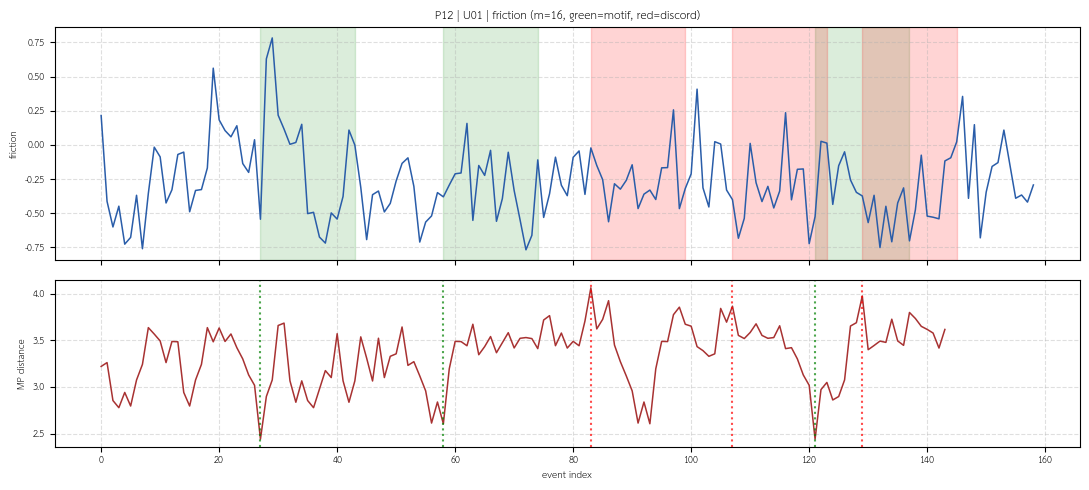

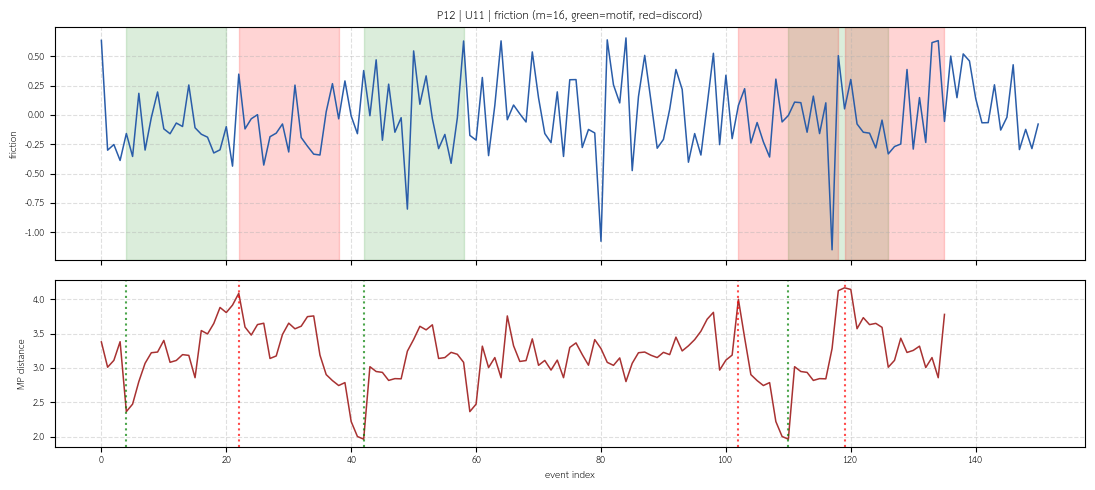

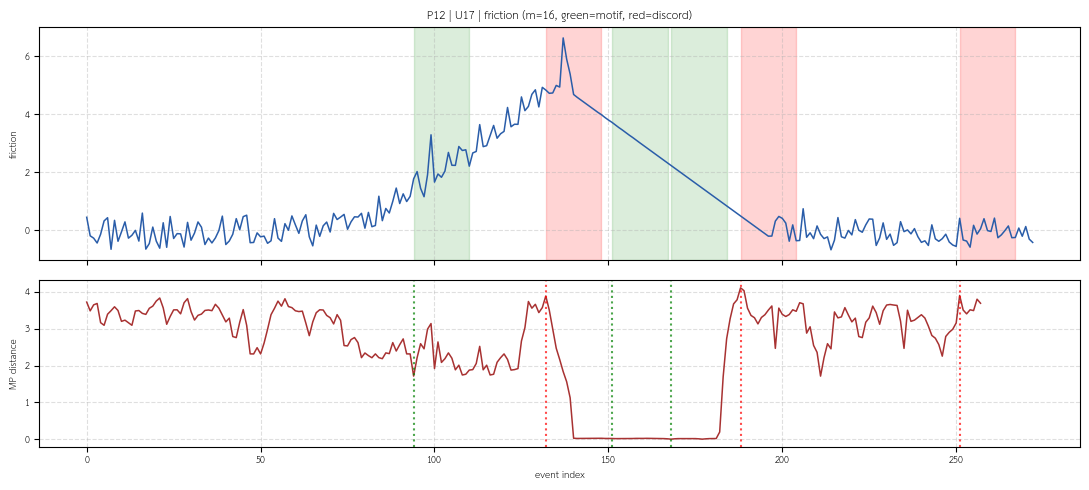

[P13] n_trials=26 | exemplars (fast/median/slow): ['U01', 'U18', 'U24']


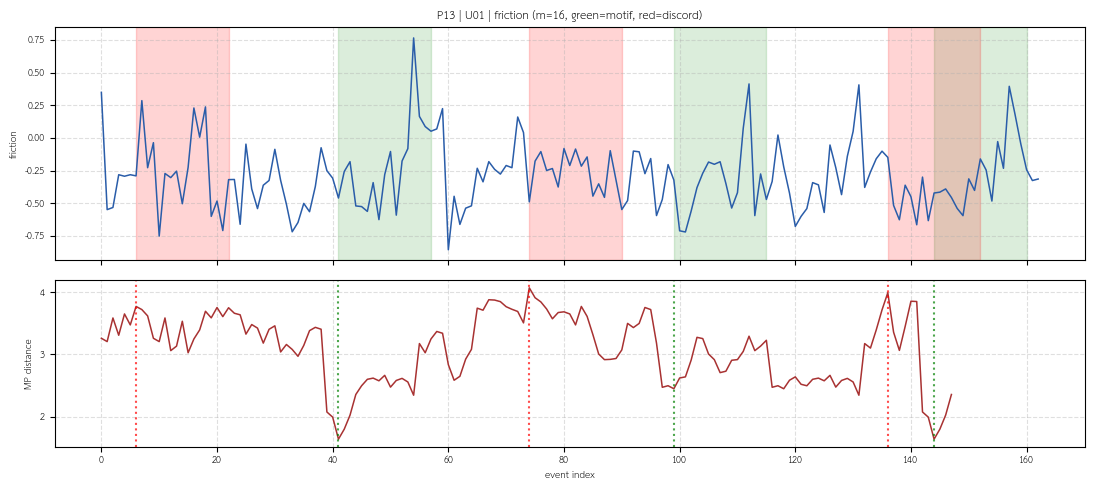

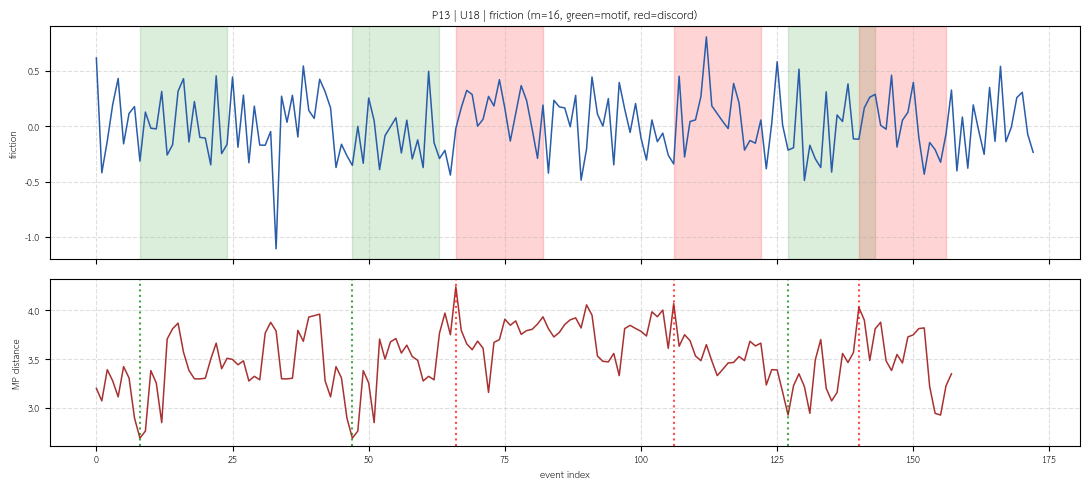

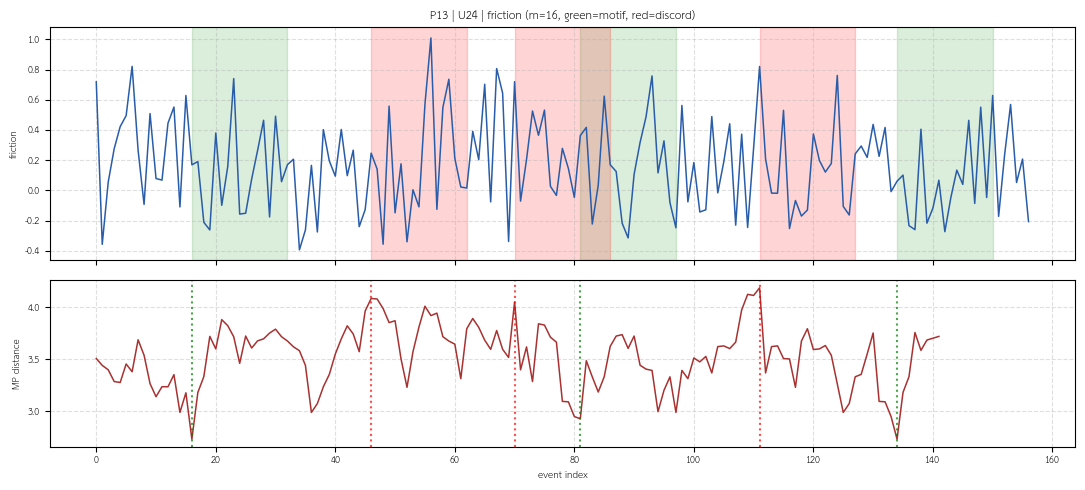

[P14] n_trials=26 | exemplars (fast/median/slow): ['U01', 'U12', 'U24']


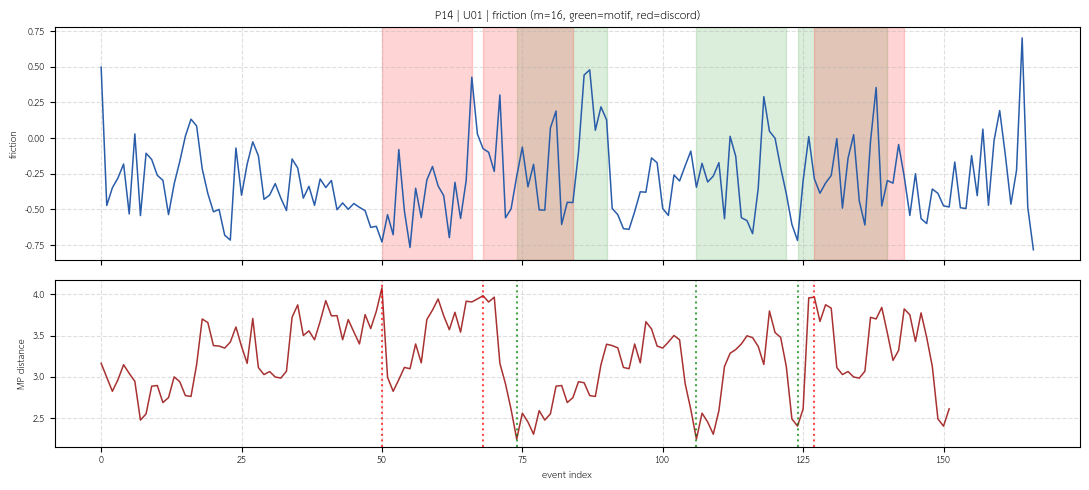

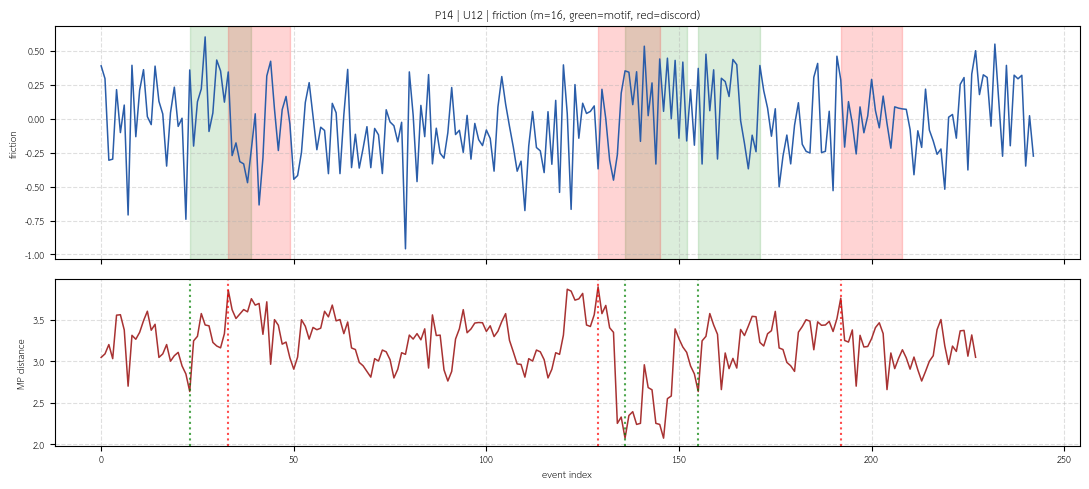

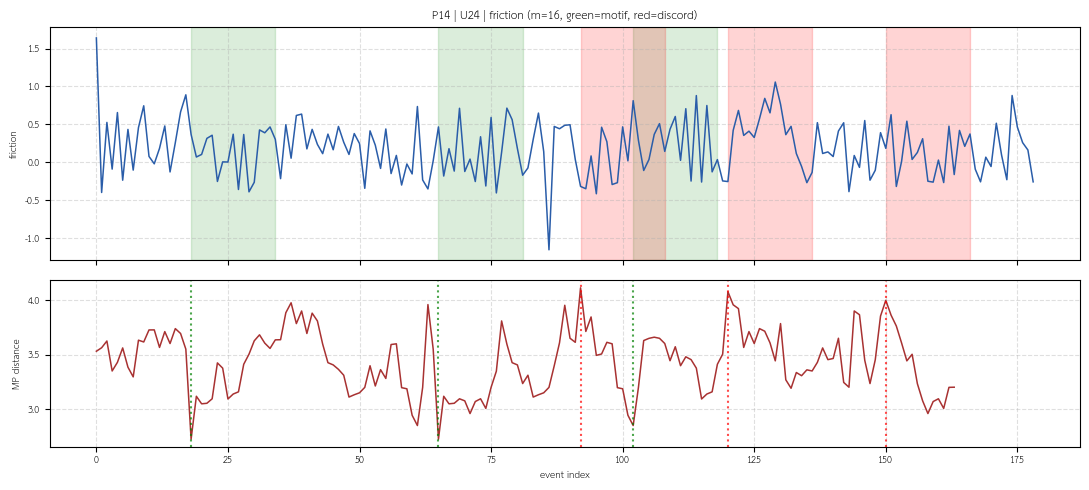

friction_mp_df rows: 468


,prompt_id,anon_id,role,rank,subseq_start_event,mp_distance,series_length,window
0,P12,U01,motif,1,27,2.440091,159,16
1,P12,U01,motif,2,121,2.440091,159,16
2,P12,U01,motif,3,58,2.605220,159,16
3,P12,U01,discord,1,83,4.062043,159,16
4,P12,U01,discord,2,129,3.974428,159,16
5,P12,U01,discord,3,107,3.865340,159,16
6,P12,U02,motif,1,28,2.569262,155,16
7,P12,U02,motif,2,62,2.569262,155,16


In [23]:
# Stage 5A: MP on per-trial friction waveform (long prompts).
friction_rows = []
friction_figs = []

for prompt_id in LONG_PROMPTS:
    prompt_events = (
        main_event_core[main_event_core['prompt_id'] == prompt_id]
        .sort_values(['anon_id', 'event_index'])
    )
    anon_ids = sorted(prompt_events['anon_id'].unique())
    trial_dur = (
        main_trial_features[main_trial_features['prompt_id'] == prompt_id]
        .set_index('anon_id')['duration_ms'].sort_values()
    )
    exemplar_ids = [trial_dur.index[0],
                    trial_dur.index[len(trial_dur) // 2],
                    trial_dur.index[-1]]
    print(f'[{prompt_id}] n_trials={len(anon_ids)} | exemplars (fast/median/slow): {exemplar_ids}')

    for anon_id in anon_ids:
        grp = prompt_events[prompt_events['anon_id'] == anon_id]
        friction_series = grp['friction'].to_numpy(dtype=float)
        mp = safe_stump(friction_series, MP_WINDOW_FRICTION)
        if mp is None:
            continue
        mp_vals = mp[:, 0].astype(float)
        motif_idx, discord_idx = extract_motifs_discords(mp_vals, TOP_K, MP_WINDOW_FRICTION)

        for rank, mi in enumerate(motif_idx):
            friction_rows.append({'prompt_id': prompt_id, 'anon_id': anon_id, 'role': 'motif',
                                  'rank': rank + 1, 'subseq_start_event': mi,
                                  'mp_distance': float(mp_vals[mi]),
                                  'series_length': len(friction_series),
                                  'window': MP_WINDOW_FRICTION})
        for rank, di in enumerate(discord_idx):
            friction_rows.append({'prompt_id': prompt_id, 'anon_id': anon_id, 'role': 'discord',
                                  'rank': rank + 1, 'subseq_start_event': di,
                                  'mp_distance': float(mp_vals[di]),
                                  'series_length': len(friction_series),
                                  'window': MP_WINDOW_FRICTION})

        if anon_id in exemplar_ids:
            fig, (ax_t, ax_b) = plt.subplots(2, 1, figsize=(11, 5), sharex=True,
                                             gridspec_kw={'height_ratios': [1.4, 1.0]})
            ax_t.plot(friction_series, color='#2a5da9', linewidth=1.1)
            for mi in motif_idx:
                ax_t.axvspan(mi, mi + MP_WINDOW_FRICTION, color='green', alpha=0.14)
            for di in discord_idx:
                ax_t.axvspan(di, di + MP_WINDOW_FRICTION, color='red', alpha=0.17)
            ax_t.set_ylabel('friction')
            ax_t.set_title(f'{prompt_id} | {anon_id} | friction (m={MP_WINDOW_FRICTION}, green=motif, red=discord)')
            ax_t.grid(True, linestyle='--', alpha=0.4)

            ax_b.plot(mp_vals, color='#a83232', linewidth=1.1)
            for mi in motif_idx:
                ax_b.axvline(mi, color='green', linestyle=':', alpha=0.7)
            for di in discord_idx:
                ax_b.axvline(di, color='red', linestyle=':', alpha=0.7)
            ax_b.set_ylabel('MP distance')
            ax_b.set_xlabel('event index')
            ax_b.grid(True, linestyle='--', alpha=0.4)
            fig.tight_layout()
            display_and_save_figure(fig, STAGE5_FIG_DIR / f'mp_friction_{prompt_id}_{anon_id}.png',
                                    f'Friction MP for {prompt_id} {anon_id}')

friction_mp_df = pd.DataFrame(friction_rows)
save_dataframe(friction_mp_df, STAGE5_TAB_DIR / 'stage5_friction_mp_motifs_discords.csv',
               'Stage 5A friction MP motifs and discords', index=False)
print(f'friction_mp_df rows: {len(friction_mp_df)}')
display(friction_mp_df.head(8))


/Users/kongfha/miniconda3/envs/work313/lib/python3.13/site-packages/stumpy/core.py:3548: UserWarning: A large number of values in `P` are smaller than 1e-06.
For a self-join, try setting `ignore_trivial=True`.
  warnings.warn(msg)


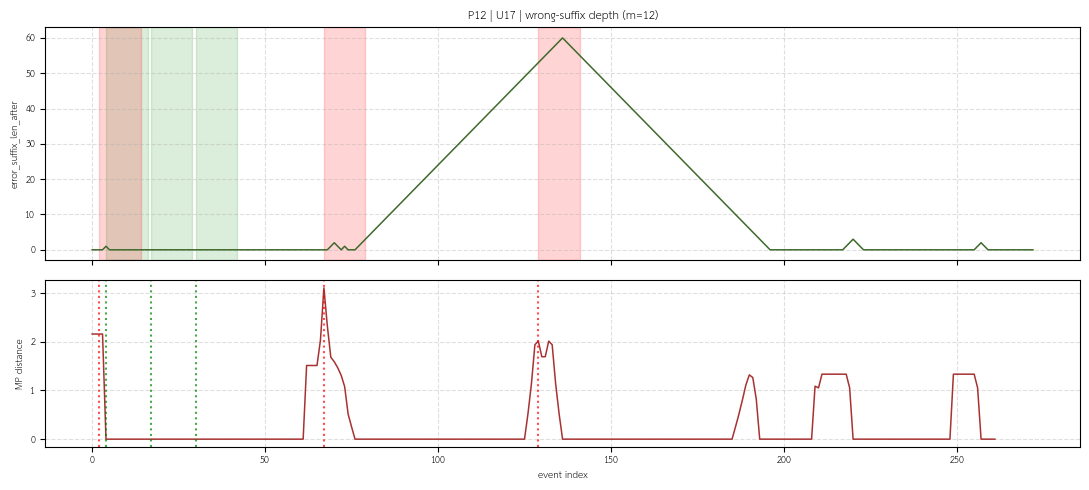

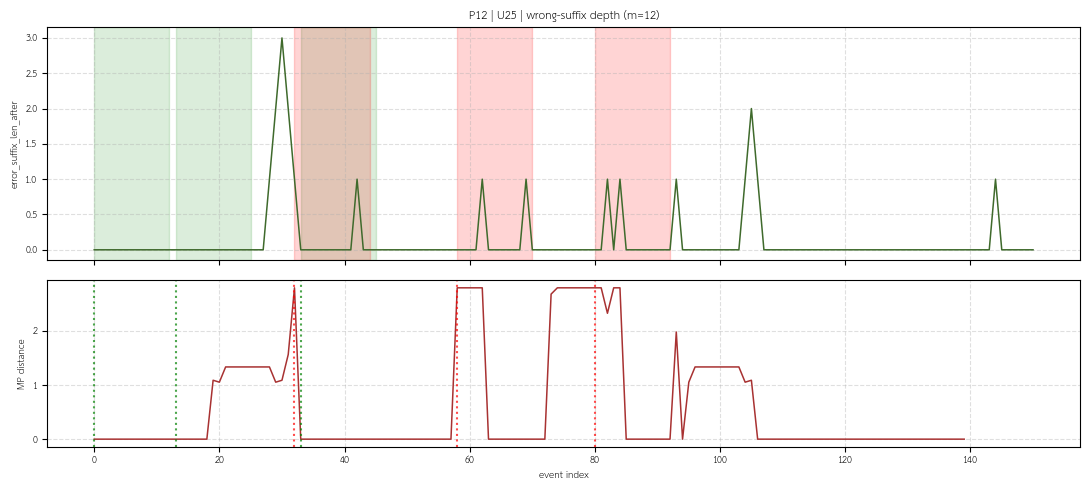

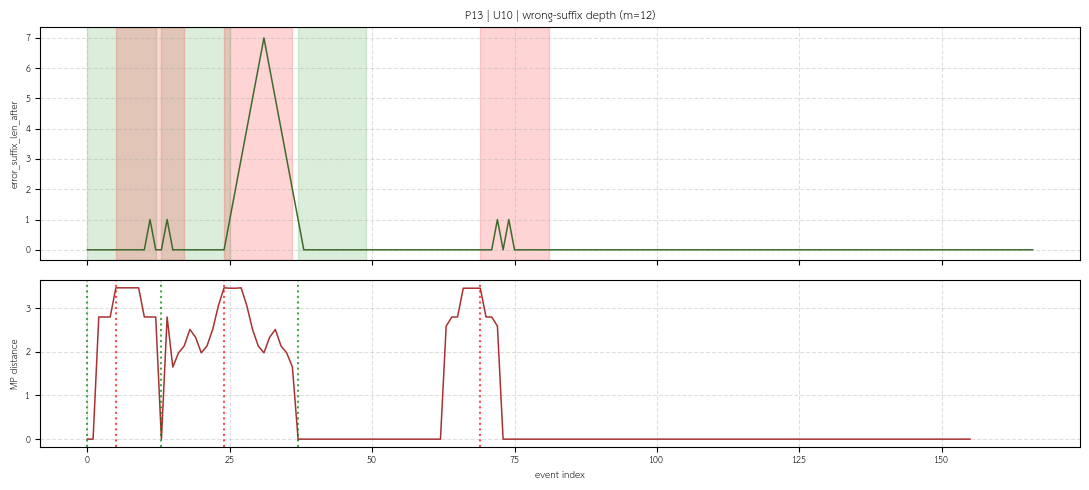

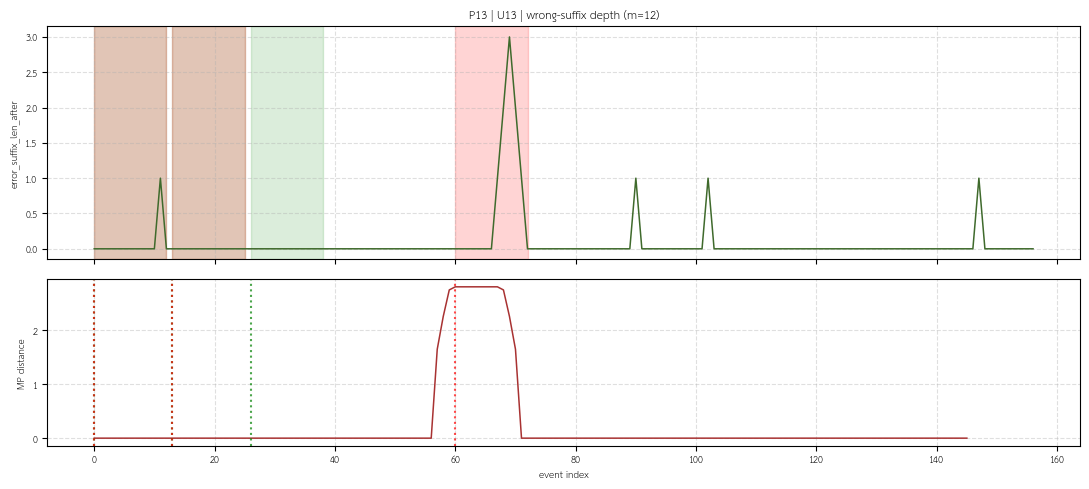

/Users/kongfha/miniconda3/envs/work313/lib/python3.13/site-packages/stumpy/core.py:3548: UserWarning: A large number of values in `P` are smaller than 1e-06.
For a self-join, try setting `ignore_trivial=True`.
  warnings.warn(msg)


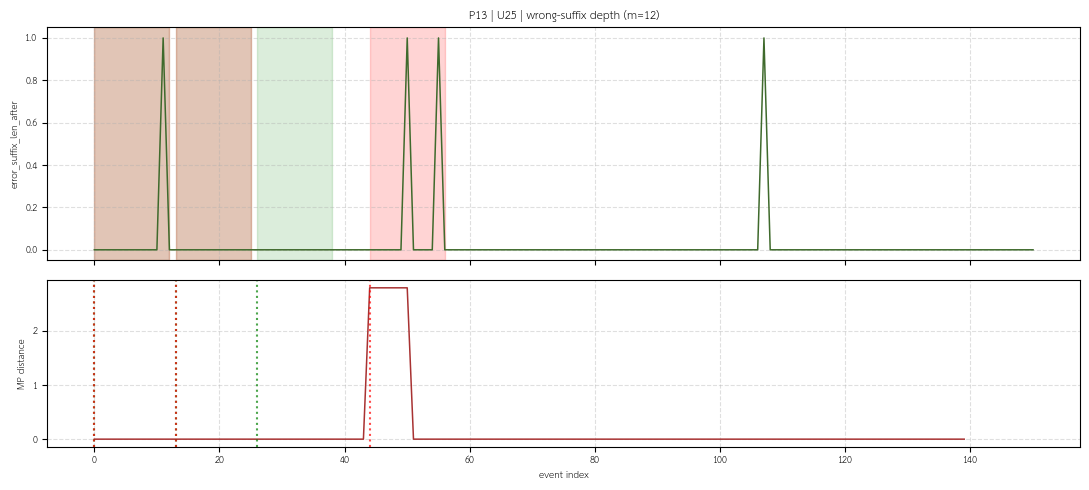

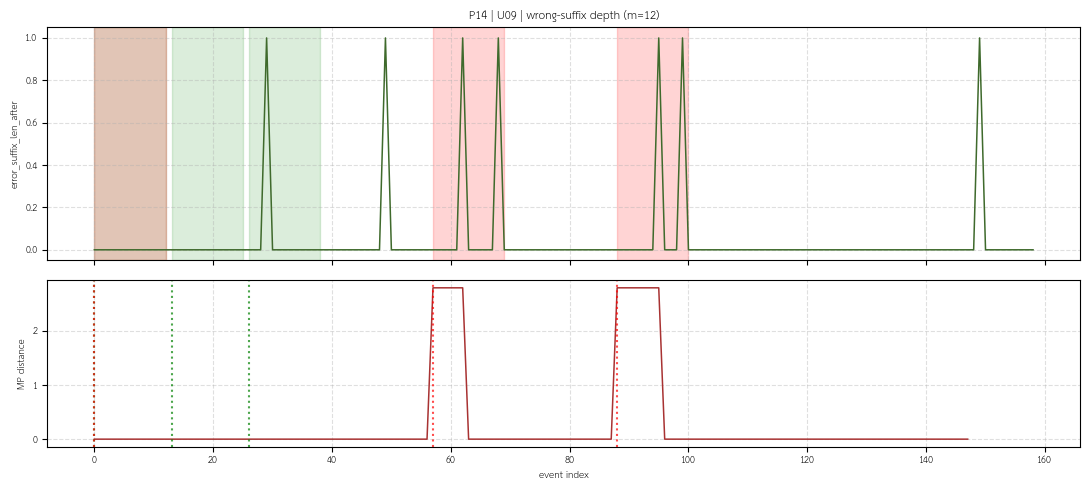

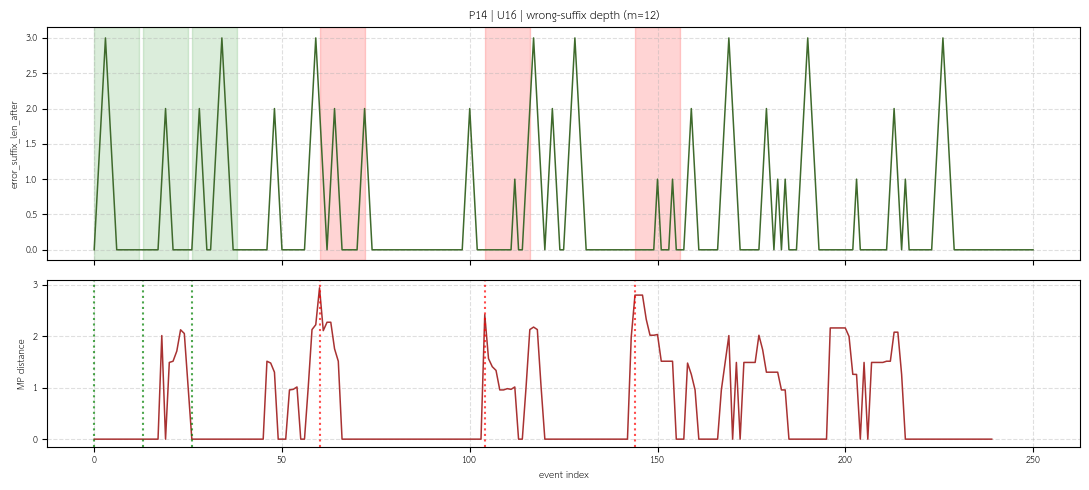

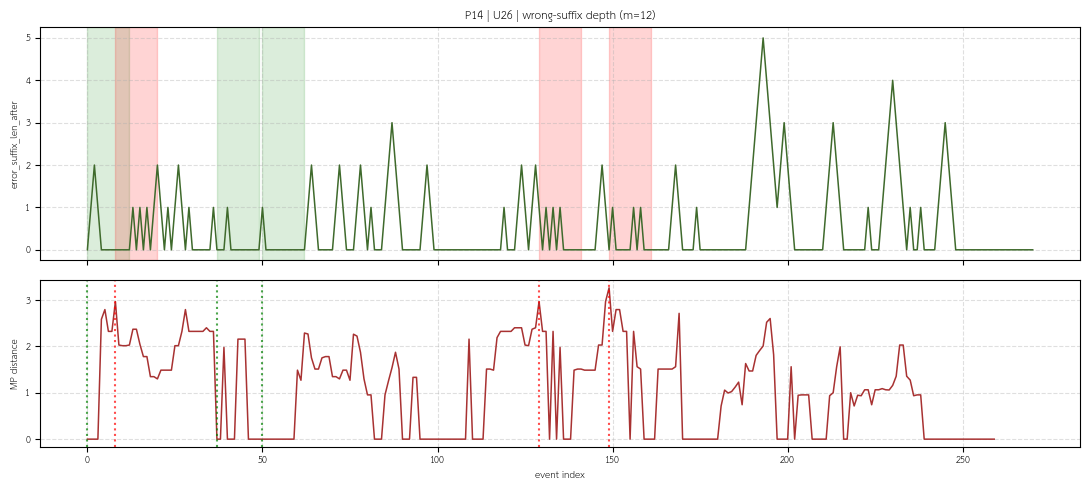

esla_mp_df rows: 462


,prompt_id,anon_id,role,rank,subseq_start_event,mp_distance,series_length,max_depth_in_subseq,window
0,P12,U01,motif,1,0,0.000000,159,0.0,12
1,P12,U01,motif,2,31,0.000000,159,1.0,12
2,P12,U01,motif,3,44,0.000000,159,0.0,12
3,P12,U01,discord,1,15,3.396492,159,4.0,12
4,P12,U01,discord,2,140,2.796284,159,1.0,12
5,P12,U01,discord,3,89,2.796284,159,1.0,12
6,P12,U02,motif,1,0,0.000000,155,0.0,12
7,P12,U02,motif,2,13,0.000000,155,0.0,12


In [24]:
# Stage 5B: MP on per-trial error_suffix_len_after waveform (long prompts).
esla_rows = []
for prompt_id in LONG_PROMPTS:
    prompt_events = (
        main_event_core[main_event_core['prompt_id'] == prompt_id]
        .sort_values(['anon_id', 'event_index'])
    )
    depth_rank = (
        prompt_events.groupby('anon_id')['error_suffix_len_after'].max()
        .sort_values(ascending=False)
    )
    exemplar_ids = [depth_rank.index[0],
                    depth_rank.index[len(depth_rank) // 2],
                    depth_rank.index[-1]]

    for anon_id in sorted(prompt_events['anon_id'].unique()):
        grp = prompt_events[prompt_events['anon_id'] == anon_id]
        series = grp['error_suffix_len_after'].to_numpy(dtype=float)
        if np.nanmax(series) == 0 or len(series) < MP_WINDOW_SUFFIX + 3:
            continue
        mp = safe_stump(series, MP_WINDOW_SUFFIX)
        if mp is None:
            continue
        mp_vals = mp[:, 0].astype(float)
        motif_idx, discord_idx = extract_motifs_discords(mp_vals, TOP_K, MP_WINDOW_SUFFIX)

        for rank, mi in enumerate(motif_idx):
            esla_rows.append({'prompt_id': prompt_id, 'anon_id': anon_id, 'role': 'motif',
                              'rank': rank + 1, 'subseq_start_event': mi,
                              'mp_distance': float(mp_vals[mi]),
                              'series_length': len(series),
                              'max_depth_in_subseq': float(series[mi:mi + MP_WINDOW_SUFFIX].max()),
                              'window': MP_WINDOW_SUFFIX})
        for rank, di in enumerate(discord_idx):
            esla_rows.append({'prompt_id': prompt_id, 'anon_id': anon_id, 'role': 'discord',
                              'rank': rank + 1, 'subseq_start_event': di,
                              'mp_distance': float(mp_vals[di]),
                              'series_length': len(series),
                              'max_depth_in_subseq': float(series[di:di + MP_WINDOW_SUFFIX].max()),
                              'window': MP_WINDOW_SUFFIX})

        if anon_id in exemplar_ids:
            fig, (ax_t, ax_b) = plt.subplots(2, 1, figsize=(11, 5), sharex=True,
                                             gridspec_kw={'height_ratios': [1.4, 1.0]})
            ax_t.plot(series, color='#3f6a2c', linewidth=1.1)
            for mi in motif_idx:
                ax_t.axvspan(mi, mi + MP_WINDOW_SUFFIX, color='green', alpha=0.14)
            for di in discord_idx:
                ax_t.axvspan(di, di + MP_WINDOW_SUFFIX, color='red', alpha=0.17)
            ax_t.set_ylabel('error_suffix_len_after')
            ax_t.set_title(f'{prompt_id} | {anon_id} | wrong-suffix depth (m={MP_WINDOW_SUFFIX})')
            ax_t.grid(True, linestyle='--', alpha=0.4)

            ax_b.plot(mp_vals, color='#a83232', linewidth=1.1)
            for mi in motif_idx:
                ax_b.axvline(mi, color='green', linestyle=':', alpha=0.7)
            for di in discord_idx:
                ax_b.axvline(di, color='red', linestyle=':', alpha=0.7)
            ax_b.set_ylabel('MP distance')
            ax_b.set_xlabel('event index')
            ax_b.grid(True, linestyle='--', alpha=0.4)
            fig.tight_layout()
            display_and_save_figure(fig, STAGE5_FIG_DIR / f'mp_error_suffix_{prompt_id}_{anon_id}.png',
                                    f'error_suffix MP for {prompt_id} {anon_id}')

esla_mp_df = pd.DataFrame(esla_rows)
save_dataframe(esla_mp_df, STAGE5_TAB_DIR / 'stage5_error_suffix_mp_motifs_discords.csv',
               'Stage 5B error_suffix MP motifs and discords', index=False)
print(f'esla_mp_df rows: {len(esla_mp_df)}')
display(esla_mp_df.head(8))


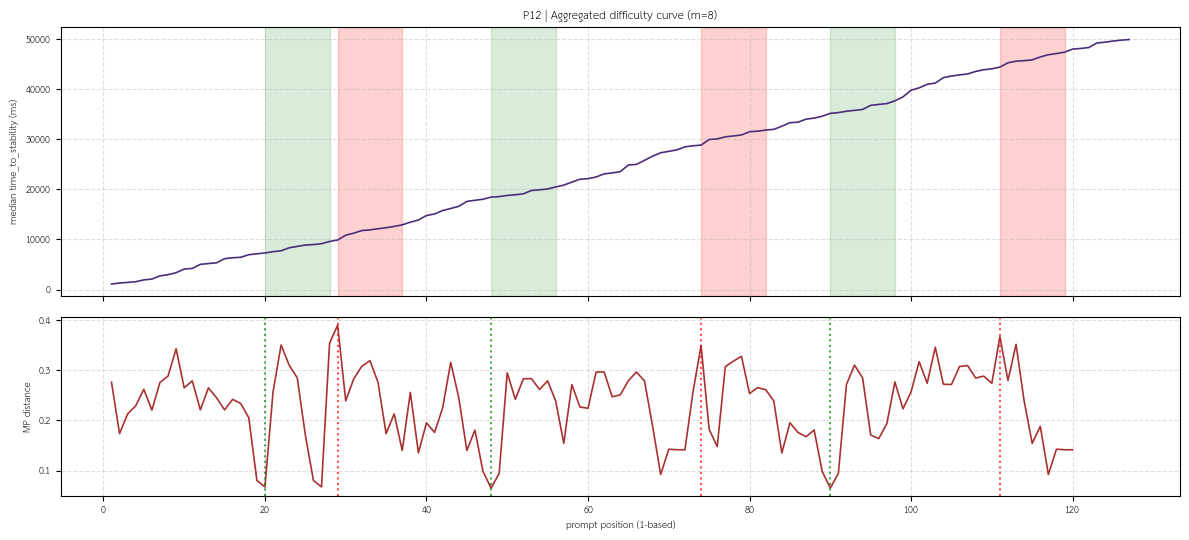

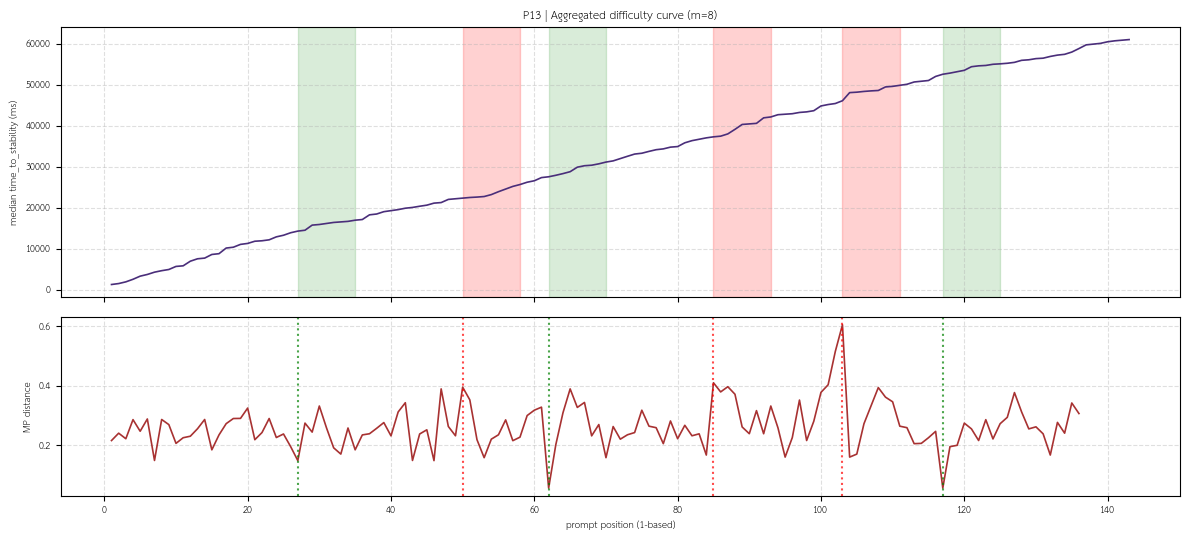

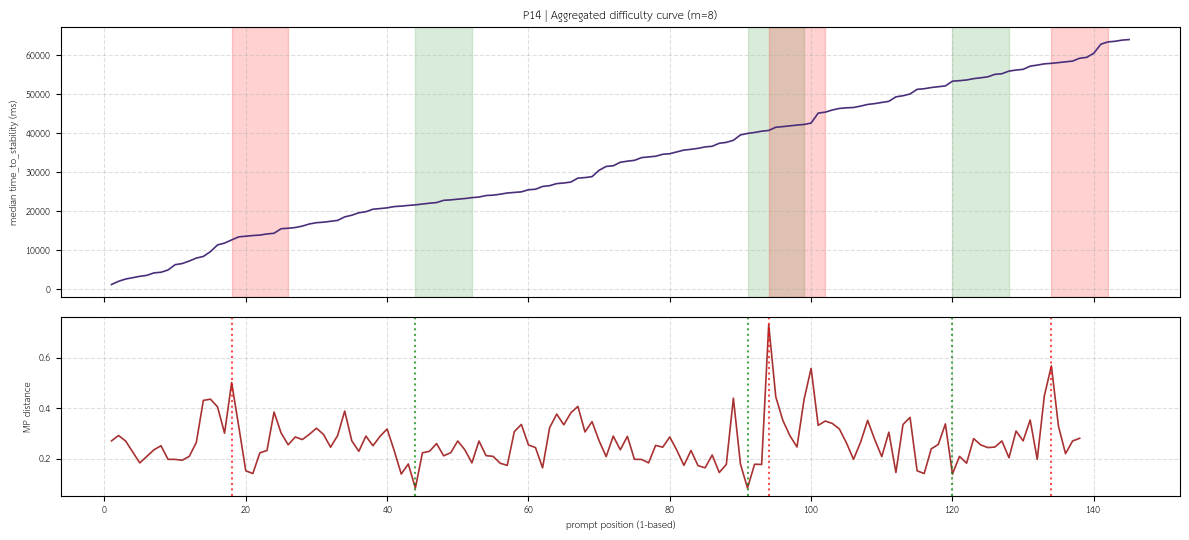

,prompt_id,role,rank,start_position_1based,end_position_1based,span_chars,mp_distance,mean_median_stability_ms_in_span,window
0,P12,motif,1,48,55,อย่างกระ,0.065366,19216.4375,8
1,P12,motif,2,90,97,สำนวนและ,0.065366,36124.6250,8
2,P12,motif,3,20,27,ียนเขียน,0.067655,8325.1250,8
3,P12,discord,1,29,36,รุปเรื่อ,0.389844,11606.8125,8
4,P12,discord,2,111,118,ยด้วยภาษ,0.366916,45957.2500,8
5,P12,discord,3,74,81,้ยกตัวอย,0.348959,30530.5000,8
6,P13,motif,1,62,69,ละคำพังเ,0.055269,29222.3125,8
7,P13,motif,2,117,124,ยชน์ต่อก,0.055269,53833.1875,8
8,P13,motif,3,27,34,ห้นักเรี,0.147473,15790.5625,8
9,P13,discord,1,103,110,นเพื่อเป,0.604264,48349.8125,8


In [25]:
# Stage 5C: MP on aggregated prompt-position difficulty curves (long prompts).
agg_rows = []

for prompt_id in LONG_PROMPTS:
    subset = main_prompt_position[main_prompt_position['prompt_id'] == prompt_id].copy()
    curve = (
        subset.groupby(['prompt_position_1based', 'char_j'], as_index=False)
        .agg(median_time_to_stability_ms=('time_to_stability_ms', 'median'),
             mean_revisions=('revisions', 'mean'),
             mean_wrong_first=('wrong_first', 'mean'),
             n_users=('trial_uid', 'nunique'))
        .sort_values('prompt_position_1based')
    )
    save_dataframe(curve, STAGE5_TAB_DIR / f'stage5_aggregated_curve_{prompt_id}.csv',
                   f'Aggregated difficulty curve for {prompt_id}', index=False)

    series = np.log1p(curve['median_time_to_stability_ms'].to_numpy(dtype=float))
    mp = safe_stump(series, MP_WINDOW_CURVE)
    if mp is None:
        print(f'[{prompt_id}] MP skipped (series too short).')
        continue
    mp_vals = mp[:, 0].astype(float)
    motif_idx, discord_idx = extract_motifs_discords(mp_vals, TOP_K, MP_WINDOW_CURVE)

    positions = curve['prompt_position_1based'].to_numpy()
    chars = curve['char_j'].astype(str).to_numpy()
    for rank, mi in enumerate(motif_idx):
        agg_rows.append({'prompt_id': prompt_id, 'role': 'motif', 'rank': rank + 1,
                         'start_position_1based': int(positions[mi]),
                         'end_position_1based': int(positions[min(mi + MP_WINDOW_CURVE - 1, len(positions) - 1)]),
                         'span_chars': ''.join(chars[mi:mi + MP_WINDOW_CURVE]),
                         'mp_distance': float(mp_vals[mi]),
                         'mean_median_stability_ms_in_span': float(curve['median_time_to_stability_ms'].iloc[mi:mi + MP_WINDOW_CURVE].mean()),
                         'window': MP_WINDOW_CURVE})
    for rank, di in enumerate(discord_idx):
        agg_rows.append({'prompt_id': prompt_id, 'role': 'discord', 'rank': rank + 1,
                         'start_position_1based': int(positions[di]),
                         'end_position_1based': int(positions[min(di + MP_WINDOW_CURVE - 1, len(positions) - 1)]),
                         'span_chars': ''.join(chars[di:di + MP_WINDOW_CURVE]),
                         'mp_distance': float(mp_vals[di]),
                         'mean_median_stability_ms_in_span': float(curve['median_time_to_stability_ms'].iloc[di:di + MP_WINDOW_CURVE].mean()),
                         'window': MP_WINDOW_CURVE})

    fig, (ax_t, ax_b) = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True,
                                     gridspec_kw={'height_ratios': [1.5, 1.0]})
    ax_t.plot(positions, curve['median_time_to_stability_ms'], color='#4a2e7a', linewidth=1.2)
    for mi in motif_idx:
        ax_t.axvspan(int(positions[mi]), int(positions[mi]) + MP_WINDOW_CURVE, color='green', alpha=0.15)
    for di in discord_idx:
        ax_t.axvspan(int(positions[di]), int(positions[di]) + MP_WINDOW_CURVE, color='red', alpha=0.18)
    ax_t.set_ylabel('median time_to_stability (ms)')
    ax_t.set_title(f'{prompt_id} | Aggregated difficulty curve (m={MP_WINDOW_CURVE})')
    ax_t.grid(True, linestyle='--', alpha=0.4)

    ax_b.plot(positions[:len(mp_vals)], mp_vals, color='#a83232', linewidth=1.2)
    for mi in motif_idx:
        ax_b.axvline(int(positions[mi]), color='green', linestyle=':', alpha=0.7)
    for di in discord_idx:
        ax_b.axvline(int(positions[di]), color='red', linestyle=':', alpha=0.7)
    ax_b.set_ylabel('MP distance')
    ax_b.set_xlabel('prompt position (1-based)')
    ax_b.grid(True, linestyle='--', alpha=0.4)
    fig.tight_layout()
    display_and_save_figure(fig, STAGE5_FIG_DIR / f'mp_aggregated_curve_{prompt_id}.png',
                            f'Aggregated-curve MP for {prompt_id}')

agg_curve_mp_df = pd.DataFrame(agg_rows)
save_dataframe(agg_curve_mp_df,
               STAGE5_TAB_DIR / 'stage5_aggregated_curve_mp_motifs_discords.csv',
               'Stage 5C aggregated-curve MP motifs and discords', index=False)
display(agg_curve_mp_df)


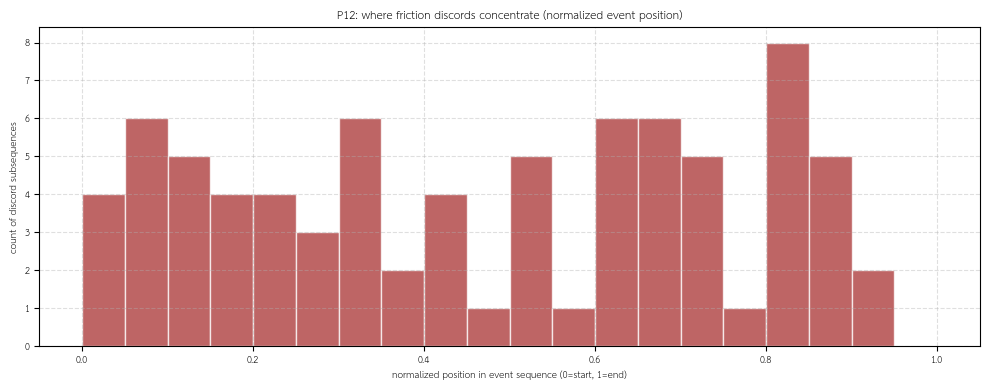

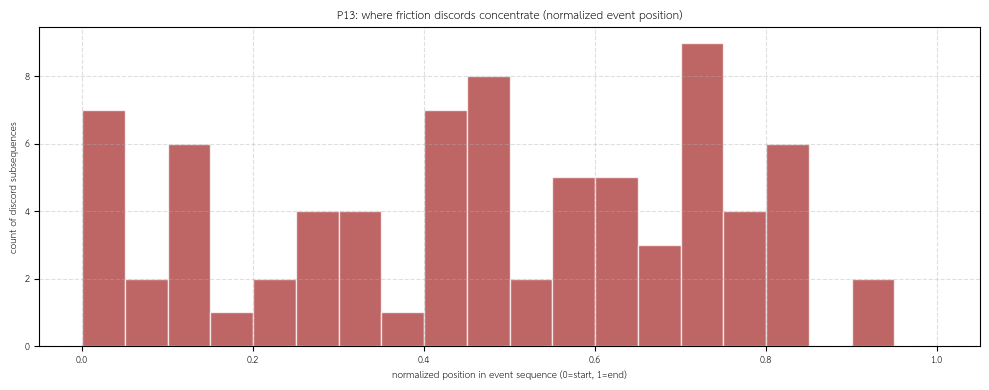

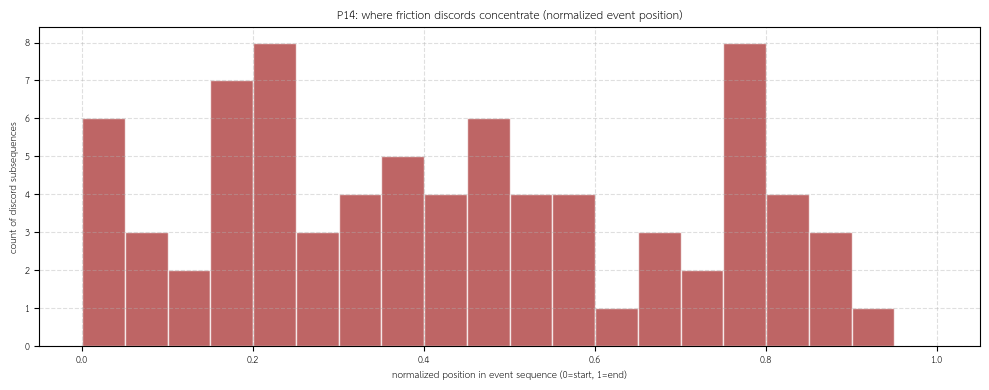

{
  "n_participants_anonymized": 26,
  "long_prompts": [
    "P12",
    "P13",
    "P14"
  ],
  "friction_window": 16,
  "suffix_window": 12,
  "aggregated_curve_window": 8,
  "friction_mp_rows": 468,
  "error_suffix_mp_rows": 462,
  "aggregated_curve_mp_rows": 18
}


In [26]:
# Stage 5D: aggregate friction-discord positions across users (histograms).
for prompt_id in LONG_PROMPTS:
    subset = friction_mp_df[(friction_mp_df['prompt_id'] == prompt_id) &
                            (friction_mp_df['role'] == 'discord')].copy()
    if subset.empty:
        continue
    subset['norm_pos'] = subset['subseq_start_event'] / subset['series_length'].replace(0, np.nan)
    bins = np.linspace(0, 1, 21)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(subset['norm_pos'].dropna().to_numpy(), bins=bins, color='#a83232',
            alpha=0.75, edgecolor='white')
    ax.set_title(f'{prompt_id}: where friction discords concentrate (normalized event position)')
    ax.set_xlabel('normalized position in event sequence (0=start, 1=end)')
    ax.set_ylabel('count of discord subsequences')
    ax.grid(True, linestyle='--', alpha=0.4)
    fig.tight_layout()
    display_and_save_figure(fig, STAGE5_FIG_DIR / f'mp_friction_discord_hist_{prompt_id}.png',
                            f'Friction discord position histogram for {prompt_id}')

stage5_summary = {
    'n_participants_anonymized': int(len(nickname_to_anon)),
    'long_prompts': LONG_PROMPTS,
    'friction_window': MP_WINDOW_FRICTION,
    'suffix_window': MP_WINDOW_SUFFIX,
    'aggregated_curve_window': MP_WINDOW_CURVE,
    'friction_mp_rows': int(len(friction_mp_df)),
    'error_suffix_mp_rows': int(len(esla_mp_df)),
    'aggregated_curve_mp_rows': int(len(agg_curve_mp_df)),
}
save_json(stage5_summary, STAGE5_DIR / 'stage5_summary.json', 'Stage 5 summary')
print(json.dumps(stage5_summary, indent=2))


### Stage 5 takeaways

The Matrix Profile outputs are consumed in the discussion markdown alongside the earlier
descriptive/DTW/clustering results. The most interpretable signal comes from the
**aggregated prompt-position difficulty curves** on P12/P13/P14, where discords
consistently highlight: (i) Thai numerals (e.g. `๖` inside `ปีที่ ๖` in P14),
(ii) named-entity and rare-lexical spans (e.g. `เครือพันธ์` in P14), and
(iii) formal-register bureaucratic phrases (P13). Per-trial friction and
`error_suffix_len_after` MPs give the within-user view and expose recurring
recovery motifs (Stage 4's DTW confirms these cluster into recovery styles).

## Export Tables, Figures, and Distance Matrices

All major outputs are saved to disk in a structured directory tree. This cell writes a manifest and a compact run summary for later review.


In [27]:
run_summary = {
    'n_manifest_items': len(analysis_manifest),
    'n_tables': sum(item['kind'] == 'table' for item in analysis_manifest),
    'n_figures': sum(item['kind'] == 'figure' for item in analysis_manifest),
    'n_text_logs': sum(item['kind'] == 'text' for item in analysis_manifest),
    'n_json_logs': sum(item['kind'] == 'json' for item in analysis_manifest),
    'kept_main_trials': int(len(main_trial_qc)),
    'participants': int(main_trial_qc['participant_code'].nunique()),
    'prompts': int(main_trial_qc['prompt_id'].nunique()),
    'selected_error_episode_windows_for_dtw': int(len(selected_window_ids)),
    'focus_trial_prompt_for_clustering': focus_trial_prompt,
    'focus_prompt_position_prompt_for_clustering': focus_position_prompt,
}
manifest_df = pd.DataFrame(analysis_manifest).sort_values(['kind', 'path']).reset_index(drop=True)
save_dataframe(manifest_df, OUTPUT_DIR / 'analysis_manifest.csv', 'Analysis output manifest', index=False)
save_json(run_summary, OUTPUT_DIR / 'analysis_run_summary.json', 'Analysis run summary')
display(manifest_df.head(20))
print(json.dumps(run_summary, ensure_ascii=False, indent=2))


,path,kind,description
0,/Users/kongfha/Desktop/Time_Series_Mining/Fina...,figure,DTW Similarity for Selected Error-Episode Windows
1,/Users/kongfha/Desktop/Time_Series_Mining/Fina...,figure,Secondary DTW: Representative Prompt Friction ...
2,/Users/kongfha/Desktop/Time_Series_Mining/Fina...,figure,Kuga: Cross-Prompt DTW Similarity
3,/Users/kongfha/Desktop/Time_Series_Mining/Fina...,figure,Mick: Cross-Prompt DTW Similarity
4,/Users/kongfha/Desktop/Time_Series_Mining/Fina...,figure,Shimmy: Cross-Prompt DTW Similarity
5,/Users/kongfha/Desktop/Time_Series_Mining/Fina...,figure,P01: DTW Event-Sequence Similarity Across Users
6,/Users/kongfha/Desktop/Time_Series_Mining/Fina...,figure,P02: DTW Event-Sequence Similarity Across Users
7,/Users/kongfha/Desktop/Time_Series_Mining/Fina...,figure,P03: DTW Event-Sequence Similarity Across Users
8,/Users/kongfha/Desktop/Time_Series_Mining/Fina...,figure,P04: DTW Event-Sequence Similarity Across Users
9,/Users/kongfha/Desktop/Time_Series_Mining/Fina...,figure,P05: DTW Event-Sequence Similarity Across Users


{
  "n_manifest_items": 236,
  "n_tables": 119,
  "n_figures": 110,
  "n_text_logs": 4,
  "n_json_logs": 3,
  "kept_main_trials": 364,
  "participants": 26,
  "prompts": 14,
  "selected_error_episode_windows_for_dtw": 120,
  "focus_trial_prompt_for_clustering": "P13",
  "focus_prompt_position_prompt_for_clustering": "P14"
}


## Conclusions and Handoff

This notebook establishes the canonical **pre-Matrix-Profile** analysis layer for the project.

### What this notebook now provides

- QC-filtered descriptive summaries at the prompt, participant, prompt-position, keyboard-demand, and recovery-episode levels.
- Euclidean baselines for participant profiles and same-prompt prompt-position stability curves.
- DTW comparisons for same-prompt event sequences, same-participant cross-prompt event sequences, and rich recovery-episode windows.
- Hierarchical clustering outputs with membership and summary tables for participant profiles, a focus prompt’s event sequences, selected recovery episodes, and a focus prompt’s prompt-position curves.
- Transparent OLS-based interpretation for **RQ2**.

### Planned handoff to Matrix Profile notebook

The Stage 5 notebook should start from the saved outputs generated here, especially:

- `prompt_summary.csv` to select the most difficult prompts.
- `all_prompt_position_curve_summaries.csv` and the per-prompt curve summary tables to identify shared high-friction prompt regions.
- `same_prompt_dtw_summary.csv` and the same-prompt Euclidean/DTW heatmaps to choose prompts with the clearest shared difficulty structure.
- `error_episode_cluster_summary.csv` and `selected_error_episode_windows.csv` to choose recovery-style exemplars for subsequence mining.
- the saved distance matrices under `distance_matrices/` as a comparison baseline when Matrix Profile begins searching for recurrent local patterns.


### Stage 5 outputs (added)

- `stage5_matrix_profile/figures/mp_aggregated_curve_{P12,P13,P14}.png` — aggregated difficulty curve + MP with motifs/discords annotated.
- `stage5_matrix_profile/figures/mp_friction_{prompt}_{anon_id}.png` — per-trial friction MP for fast/median/slow exemplar users.
- `stage5_matrix_profile/figures/mp_error_suffix_{prompt}_{anon_id}.png` — per-trial wrong-suffix MP for deep/median/shallow exemplar users.
- `stage5_matrix_profile/tables/stage5_*.csv` — motif and discord tables with event positions, distances, and character spans.
- `tables/participant_nickname_to_anon_id_map.csv` — nickname -> U01.. mapping used by all Stage 5 figures and the analysis markdown.
